# Lake Taney mooring analysis with 2026 options and miniDOT

Workflow

1. Load all historical HOBO campaigns.
2. Load post-design change (2025) Campaings.
3. Load the miniDOT temperature and dissolved oxygen record.
4. Compare 2026 options and miniDOT against the closest HOBO sensor.
5. Choose one 2026 option, decide whether to use the miniDOT as the bottom temperature sensor, and set analysis thresholds.
6. Rebuild the final analysis dataset.
7. Plot temperature, stratification, inferred ice cover, and RTRM.
8. Statistics

## 0. Imports and general settings

In [69]:
import os
import copy
import numpy as np
import pandas as pd
import netCDF4
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime
from scipy.interpolate import interp1d

try:
    import cmocean
    cmap_temperature = cmocean.cm.thermal
except Exception:
    cmap_temperature = "plasma"

# Uncomment this in JupyterLab if you want interactive figures and ipympl is installed.
# %matplotlib widget

## 1. Paths and campaign settings

The paths are relative to the `notebooks` folder.

In [70]:
# Main data folders
data_folder_hobo = os.path.join("..", "data", "Mooring", "HOBO_T")
data_folder_minidot = os.path.join("..", "data", "Mooring", "miniDOT")

# Campaign folders to include
historical_campaigns = [
    "20240527",
    "20240910",
    "20241126",
    "20250604"
]

campaign_2026 = "20260603"

# miniDOT file
minidot_campaign = "20260603"
minidot_file = "L2_mooring_minidot_583960.nc"
minidot_path = os.path.join(
    data_folder_minidot,
    minidot_campaign,
    "Level2",
    minidot_file
)

print("Current working directory:")
print(os.getcwd())

print("\nHOBO folder:")
print(data_folder_hobo)

print("\nminiDOT path:")
print(minidot_path)
print("miniDOT file exists:", os.path.exists(minidot_path))

Current working directory:
/Users/estelle/Documents/GitHub/taney-monitoring-masterfieldcamp/notebooks

HOBO folder:
../data/Mooring/HOBO_T

miniDOT path:
../data/Mooring/miniDOT/20260603/Level2/L2_mooring_minidot_583960.nc
miniDOT file exists: True


## 2. Helper functions

In [71]:
def masked_to_nan(x):
    """Convert masked arrays to regular float arrays with NaN."""
    x = np.asanyarray(x)

    if np.ma.isMaskedArray(x):
        x = x.filled(np.nan)

    return np.asarray(x, dtype=float)


def decode_netcdf_time(time_var):
    """Decode a NetCDF time variable to Unix seconds and Python datetimes."""
    time_raw = np.asanyarray(time_var[:])

    if np.ma.isMaskedArray(time_raw):
        time_raw = time_raw.filled(np.nan)

    if hasattr(time_var, "units"):
        try:
            time_dates = netCDF4.num2date(
                time_raw,
                units=time_var.units,
                calendar=getattr(time_var, "calendar", "standard"),
                only_use_cftime_datetimes=False
            )

            time_dates = np.array([
                datetime(t.year, t.month, t.day, t.hour, t.minute, t.second)
                for t in time_dates
            ])

            time_num = np.array([
                np.datetime64(t, "s").astype("int64")
                for t in time_dates
            ], dtype=float)

            return time_num, time_dates

        except Exception as e:
            print("num2date failed, trying Unix seconds:", e)

    time_num = time_raw.astype(float)
    time_dates = time_num.astype("datetime64[s]").astype(datetime)

    return time_num, time_dates


def read_l3_file(filepath):
    """Read one HOBO Level3 file and return time, depth, temp in depth x time format."""
    with netCDF4.Dataset(filepath) as nc:
        time_var = nc.variables["time"]
        time_num, time_date = decode_netcdf_time(time_var)

        depth = masked_to_nan(nc.variables["depth"][:])
        temp = masked_to_nan(nc.variables["temp"][:])

        # Some Level3 files store depth as a 2D field (one value per sensor per
        # timestep) instead of a 1D coordinate (one nominal depth per sensor).
        # Collapse any 2D depth to a single representative depth per sensor so
        # the rest of the notebook can always treat depth as 1D (n_depth,).
        depth = np.asarray(depth, dtype=float)
        if depth.ndim > 1:
            depth = np.nanmean(depth, axis=1)

        n_depth = len(depth)
        n_time = len(time_num)

        if temp.shape == (n_time, n_depth):
            temp = temp.T
        elif temp.shape != (n_depth, n_time):
            raise ValueError(
                "Unexpected temp shape {} in {}. Expected {} or {}.".format(
                    temp.shape,
                    filepath,
                    (n_depth, n_time),
                    (n_time, n_depth)
                )
            )

    return time_num, time_date, depth, temp


def interpolate_profile_to_grid(depth, temp, depth_grid):
    """Interpolate a depth x time temperature matrix to a new depth grid."""
    order = np.argsort(depth)
    depth_sorted = depth[order]
    temp_sorted = temp[order, :]

    f = interp1d(
        depth_sorted,
        temp_sorted,
        axis=0,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    return f(depth_grid)


def interp_with_nans(x_old, y_old, x_new):
    """1D interpolation that ignores NaN values and avoids extrapolation."""
    x_old = np.asarray(x_old, dtype=float)
    y_old = np.asarray(y_old, dtype=float)
    x_new = np.asarray(x_new, dtype=float)

    valid = np.isfinite(x_old) & np.isfinite(y_old)
    y_new = np.full(len(x_new), np.nan)

    if np.sum(valid) < 2:
        return y_new

    x_valid = x_old[valid]
    y_valid = y_old[valid]

    order = np.argsort(x_valid)
    x_valid = x_valid[order]
    y_valid = y_valid[order]

    inside = (x_new >= x_valid[0]) & (x_new <= x_valid[-1])

    y_new[inside] = np.interp(
        x_new[inside],
        x_valid,
        y_valid
    )

    return y_new


def water_density(T_C):
    """Freshwater density in kg m-3 from temperature in degrees Celsius."""
    return (
        999.842594
        + 6.793952e-2 * T_C
        - 9.095290e-3 * T_C**2
        + 1.001685e-4 * T_C**3
        - 1.120083e-6 * T_C**4
        + 6.536332e-9 * T_C**5
    )


def find_continuous_runs(mask, time_num, max_gap_factor=3):
    """Find continuous True runs, resetting when there are large time gaps."""
    mask = np.asarray(mask, dtype=bool)
    dt_sec = np.median(np.diff(time_num))

    runs = []
    current_start = None
    current_len = 0

    for kt in range(len(mask)):
        if kt > 0:
            gap_too_large = (time_num[kt] - time_num[kt - 1]) > max_gap_factor * dt_sec
        else:
            gap_too_large = False

        if gap_too_large:
            if current_start is not None:
                runs.append((current_start, kt - 1, current_len))

            current_start = None
            current_len = 0

        if mask[kt]:
            if current_start is None:
                current_start = kt

            current_len += 1

        else:
            if current_start is not None:
                runs.append((current_start, kt - 1, current_len))

            current_start = None
            current_len = 0

    if current_start is not None:
        runs.append((current_start, len(mask) - 1, current_len))

    return runs

## 3. Load historical HOBO campaigns

This loads all old campaigns except the special 2026 deployment. A campaign is skipped if its temperature matrix is fully empty.

In [72]:
historical_records = []

for camp in historical_campaigns:
    folder = os.path.join(data_folder_hobo, camp, "Level3")

    if not os.path.exists(folder):
        print("Skipping {} because Level3 folder does not exist".format(camp))
        continue

    files = [
        f for f in os.listdir(folder)
        if f.endswith(".nc") and f.startswith("L3_mooring") and "chain" not in f.lower()
    ]

    if len(files) == 0:
        print("Skipping {} because no matching Level3 file was found".format(camp))
        continue

    if len(files) > 1:
        raise RuntimeError("More than one historical Level3 file found for {}: {}".format(camp, files))

    filepath = os.path.join(folder, files[0])

    time_num_camp, time_date_camp, depth, temp = read_l3_file(filepath)

    if np.all(np.isnan(temp)):
        print("Skipping {} because temperature matrix is entirely NaN".format(camp))
        continue

    historical_records.append({
        "camp": camp,
        "source": "historical",
        "label": camp,
        "file": files[0],
        "time": time_num_camp,
        "time_date": time_date_camp,
        "depth": depth,
        "temp": temp
    })

    print(
        "Loaded {} | {} | depths {:.2f}-{:.2f} m | {} depths | {} time steps".format(
            camp,
            files[0],
            np.nanmin(depth),
            np.nanmax(depth),
            len(depth),
            len(time_num_camp)
        )
    )

print("\nHistorical records loaded:", len(historical_records))

Loaded 20240527 | L3_mooring_20240315_123000.nc | depths 0.00-25.00 m | 10 depths | 10515 time steps
Loaded 20240910 | L3_mooring_20240528_100000.nc | depths 0.00-25.00 m | 9 depths | 15156 time steps
Loaded 20241126 | L3_mooring_20240910_170000.nc | depths 0.00-25.00 m | 10 depths | 11076 time steps
Loaded 20250604 | L3_mooring_20250428_123000.nc | depths 0.00-25.00 m | 10 depths | 5333 time steps

Historical records loaded: 4


## 4. Load all 2026 HOBO options

This cell loads every Level3 file found for `20260603`. The labels are generated automatically from file names. This lets you compare the unified option, chain A, chain B, or any other candidate file before choosing one for analysis.

In [73]:
def label_2026_file(filename):
    """Create a readable label for each 2026 candidate file."""
    lower = filename.lower()

    if "chaina" in lower or "chain_a" in lower or "_a" in lower:
        return "chainA"

    if "chainb" in lower or "chain_b" in lower or "_b" in lower:
        return "chainB"

    if "chain" not in lower:
        return "unified"

    return os.path.splitext(filename)[0]


folder_2026 = os.path.join(data_folder_hobo, campaign_2026, "Level3")

if not os.path.exists(folder_2026):
    raise FileNotFoundError("2026 Level3 folder not found: {}".format(folder_2026))

files_2026 = [
    f for f in os.listdir(folder_2026)
    if f.endswith(".nc") and f.startswith("L3_mooring")
]

if len(files_2026) == 0:
    raise FileNotFoundError("No 2026 Level3 NetCDF files found in {}".format(folder_2026))

records_2026 = {}

for fname in sorted(files_2026):
    label = label_2026_file(fname)

    if label in records_2026:
        label = os.path.splitext(fname)[0]

    filepath = os.path.join(folder_2026, fname)

    time_num_2026, time_date_2026, depth, temp = read_l3_file(filepath)

    if np.all(np.isnan(temp)):
        print("Skipping 2026 candidate {} because it is entirely NaN".format(fname))
        continue

    records_2026[label] = {
        "camp": campaign_2026,
        "source": "2026",
        "label": label,
        "file": fname,
        "time": time_num_2026,
        "time_date": time_date_2026,
        "depth": depth,
        "temp": temp
    }

    print(
        "Loaded 2026 candidate {} | {} | depths {:.2f}-{:.2f} m | {} depths | {} time steps".format(
            label,
            fname,
            np.nanmin(depth),
            np.nanmax(depth),
            len(depth),
            len(time_num_2026)
        )
    )

if len(records_2026) == 0:
    raise RuntimeError("No valid 2026 HOBO candidate was loaded.")

print("\nAvailable 2026 candidates:")
print(list(records_2026.keys()))

Loaded 2026 candidate chainA | L3_mooring_option3A_chainA_20250606_103900.nc | depths 0.70-12.53 m | 7 depths | 32509 time steps
Loaded 2026 candidate chainB | L3_mooring_option3A_chainB_20250606_103900.nc | depths 13.50-15.60 m | 2 depths | 32509 time steps
Loaded 2026 candidate unified | L3_mooring_option3B_20250606_103900.nc | depths 0.70-15.60 m | 9 depths | 32509 time steps

Available 2026 candidates:
['chainA', 'chainB', 'unified']


## 5. Load miniDOT temperature and dissolved oxygen

The miniDOT is a bottom sensor at 31.8 m. Temperature can potentially be used to extend the 2026 thermal profile downward. Dissolved oxygen is kept as a separate diagnostic variable.

In [74]:
# miniDOT quality filtering settings.
# In the diagnostic output, the quality variables were 0 or 1.
# Here 0 is treated as good by default.
# If this removes too many values, set apply_minidot_quality_flags = False.

apply_minidot_quality_flags = True
good_quality_value = 0

if not os.path.exists(minidot_path):
    raise FileNotFoundError("miniDOT file not found: {}".format(minidot_path))

with netCDF4.Dataset(minidot_path) as nc:
    mini_time_num, mini_time_date = decode_netcdf_time(nc.variables["time"])

    mini_temp_raw = masked_to_nan(nc.variables["Temp"][:])
    mini_do_raw = masked_to_nan(nc.variables["DO_mg"][:])
    mini_sat_raw = masked_to_nan(nc.variables["sat"][:])

    mini_temp_qual = masked_to_nan(nc.variables["Temp_qual"][:])
    mini_do_qual = masked_to_nan(nc.variables["DO_mg_qual"][:])
    mini_sat_qual = masked_to_nan(nc.variables["sat_qual"][:])

    minidot_depth = float(nc.variables["depth"][:])

mini_temp = mini_temp_raw.copy()
mini_do = mini_do_raw.copy()
mini_sat = mini_sat_raw.copy()

if apply_minidot_quality_flags:
    mini_temp[mini_temp_qual != good_quality_value] = np.nan
    mini_do[mini_do_qual != good_quality_value] = np.nan
    mini_sat[mini_sat_qual != good_quality_value] = np.nan

print("miniDOT loaded")
print("  depth: {:.2f} m".format(minidot_depth))
print("  period:", mini_time_date[0], "to", mini_time_date[-1])
print("  raw valid Temp:", np.sum(~np.isnan(mini_temp_raw)))
print("  filtered valid Temp:", np.sum(~np.isnan(mini_temp)))
print("  raw valid DO:", np.sum(~np.isnan(mini_do_raw)))
print("  filtered valid DO:", np.sum(~np.isnan(mini_do)))

if np.sum(~np.isnan(mini_temp)) > 0:
    print("  Temp min/max: {:.2f} / {:.2f} °C".format(np.nanmin(mini_temp), np.nanmax(mini_temp)))

if np.sum(~np.isnan(mini_do)) > 0:
    print("  DO min/max: {:.2f} / {:.2f} mg/L".format(np.nanmin(mini_do), np.nanmax(mini_do)))

miniDOT loaded
  depth: 31.80 m
  period: 2025-06-06 06:57:00 to 2026-06-03 13:46:00
  raw valid Temp: 521431
  filtered valid Temp: 521431
  raw valid DO: 521431
  filtered valid DO: 521431
  Temp min/max: 3.15 / 5.38 °C
  DO min/max: 0.09 / 9.02 mg/L


Use this in the cleaning cell:
retrieval_cutoff_2026 = "2026-01-18 03:09:00"


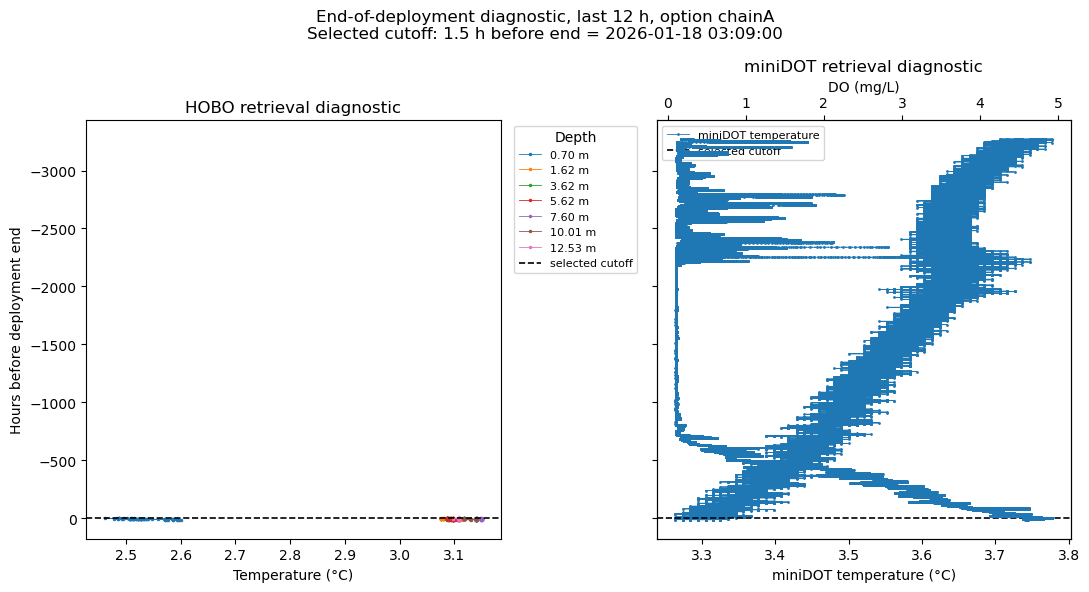

In [75]:
### End-of-deployment diagnostic: choose cutoff from hours before retrieval

# This plot uses:
#   x-axis = temperature / DO
#   y-axis = hours before the end of the deployment
#
# This makes it easier to choose a cutoff visually.
# Then adjust cutoff_hours_before_end below.

hours_to_show = 12
cutoff_hours_before_end = 1.5   # change this after looking at the graph

option_to_check = "chainA"   # or "chainB"

if option_to_check not in records_2026:
    raise ValueError(
        "option_to_check must be one of {}".format(list(records_2026.keys()))
    )

rec = records_2026[option_to_check]

t = rec["time"]
depth = rec["depth"]
temp = rec["temp"]

t_end = np.nanmax(t)
hours_before_end = (t_end - t) / 3600

mask = hours_before_end <= hours_to_show

# Convert selected cutoff in hours to actual datetime string
cutoff_num = t_end - cutoff_hours_before_end * 3600
retrieval_cutoff_2026 = np.datetime64(int(cutoff_num), "s").astype(datetime).strftime("%Y-%m-%d %H:%M:%S")

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)

# ── HOBO temperatures ───────────────────────────────────────────────────────

for kd, d in enumerate(depth):
    axes[0].plot(
        temp[kd, mask],
        hours_before_end[mask],
        marker=".",
        markersize=3,
        linewidth=0.6,
        label="{:.2f} m".format(d)
    )

axes[0].axhline(
    cutoff_hours_before_end,
    linestyle="--",
    color="k",
    linewidth=1.2,
    label="selected cutoff"
)

axes[0].invert_yaxis()
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Hours before deployment end")
axes[0].set_title("HOBO retrieval diagnostic")
axes[0].legend(
    title="Depth",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)


# ── miniDOT temperature and DO ──────────────────────────────────────────────

if "mini_time_num" in globals() and "mini_temp" in globals():

    mini_hours_before_end = (t_end - mini_time_num) / 3600
    mask_md = mini_hours_before_end <= hours_to_show

    axes[1].plot(
        mini_temp[mask_md],
        mini_hours_before_end[mask_md],
        marker=".",
        markersize=2,
        linewidth=0.6,
        label="miniDOT temperature"
    )

    if "mini_do" in globals():

        ax2 = axes[1].twiny()

        ax2.plot(
            mini_do[mask_md],
            mini_hours_before_end[mask_md],
            marker=".",
            markersize=2,
            linewidth=0.6,
            linestyle="--",
            label="miniDOT DO"
        )

        ax2.set_xlabel("DO (mg/L)")

    axes[1].axhline(
        cutoff_hours_before_end,
        linestyle="--",
        color="k",
        linewidth=1.2,
        label="selected cutoff"
    )

    axes[1].set_xlabel("miniDOT temperature (°C)")
    axes[1].set_title("miniDOT retrieval diagnostic")
    axes[1].legend(fontsize=8)

else:

    axes[1].text(
        0.5,
        0.5,
        "miniDOT not loaded",
        ha="center",
        va="center",
        transform=axes[1].transAxes
    )

fig.suptitle(
    "End-of-deployment diagnostic, last {} h, option {}\nSelected cutoff: {} h before end = {}".format(
        hours_to_show,
        option_to_check,
        cutoff_hours_before_end,
        retrieval_cutoff_2026
    )
)

fig.tight_layout()

print("Use this in the cleaning cell:")
print('retrieval_cutoff_2026 = "{}"'.format(retrieval_cutoff_2026))

In [76]:
### Clean retrieval artefact for 2026 data only

# This cell removes the last unreliable measurements from the 2026 deployment.
#
# Why?
#   At the end of a deployment, the mooring is pulled up through the water column.
#   During that retrieval period, sensors are no longer at their nominal depths.
#   These final points can therefore create false signals in the temperature grid,
#   stratification timing, ice-cover timing, RTRM, and DO interpretation.
#
# What this cell does:
#   1) Keeps the raw 2026 data safely stored as records_2026_raw.
#   2) Creates cleaned copies where all values after the cutoff are set to NaN.
#   3) Replaces the working 2026 and miniDOT variables with cleaned versions.
#   4) Clears old derived variables, so the rest of the notebook must be rerun
#      and cannot accidentally use stale pre-cleaning results.
#
# Historical campaigns are not modified here.

import copy
import numpy as np

# ── User input ──────────────────────────────────────────────────────────────

# Set this just before the retrieval artefact starts.
# Use the diagnostic plot above to choose this timestamp.
#
# Format:
#   "YYYY-MM-DD HH:MM:SS"

retrieval_cutoff_2026 = "2026-06-03 12:00:00"

# If True, the rest of the notebook will use the cleaned 2026 and miniDOT data.
# This is usually what you want for final analysis.

apply_cleaning_to_working_variables = True


# ── Preserve raw 2026 data once ─────────────────────────────────────────────

# These *_raw variables are created only the first time this cell is run.
# This means you can change retrieval_cutoff_2026 and rerun the cell safely.

if "records_2026_raw" not in globals():
    records_2026_raw = copy.deepcopy(records_2026)

if "mini_time_num" in globals() and "mini_time_num_raw" not in globals():
    mini_time_num_raw = mini_time_num.copy()
    mini_time_date_raw = mini_time_date.copy()
    mini_temp_raw = mini_temp.copy()
    mini_do_raw = mini_do.copy()
    mini_sat_raw = mini_sat.copy()


# ── Helper functions ────────────────────────────────────────────────────────

def datetime_string_to_unix_seconds(date_string):
    """
    Convert a date string to Unix seconds.
    """
    return np.datetime64(date_string, "s").astype("int64")


def clean_record_after_cutoff(record, cutoff_num):
    """
    Return a cleaned copy of one 2026 HOBO record.

    Temperatures after the cutoff are set to NaN.
    The time vector is kept unchanged so all arrays remain aligned.
    """

    r = copy.deepcopy(record)

    after_cutoff = r["time"] > cutoff_num

    if np.any(after_cutoff):
        r["temp"][:, after_cutoff] = np.nan

    return r, np.sum(after_cutoff)


# ── Apply cutoff to all 2026 HOBO options ───────────────────────────────────

cutoff_num = datetime_string_to_unix_seconds(retrieval_cutoff_2026)

print("Retrieval cutoff:", retrieval_cutoff_2026)

records_2026_clean = {}

for key, r in records_2026_raw.items():

    r_clean, n_cleaned = clean_record_after_cutoff(r, cutoff_num)
    records_2026_clean[key] = r_clean

    print(
        "2026 option {}: set {} time steps after cutoff to NaN".format(
            key,
            n_cleaned
        )
    )


# ── Apply cutoff to miniDOT ─────────────────────────────────────────────────

# miniDOT time is kept unchanged.
# Only temperature, dissolved oxygen, and saturation are set to NaN after the cutoff.

if "mini_time_num_raw" in globals():

    mini_time_num_clean = mini_time_num_raw.copy()
    mini_time_date_clean = mini_time_date_raw.copy()
    mini_temp_clean = mini_temp_raw.copy()
    mini_do_clean = mini_do_raw.copy()
    mini_sat_clean = mini_sat_raw.copy()

    after_cutoff_md = mini_time_num_clean > cutoff_num

    mini_temp_clean[after_cutoff_md] = np.nan
    mini_do_clean[after_cutoff_md] = np.nan
    mini_sat_clean[after_cutoff_md] = np.nan

    print(
        "miniDOT: set {} values after cutoff to NaN".format(
            np.sum(after_cutoff_md)
        )
    )

else:

    print("miniDOT variables not found. Only 2026 HOBO records were cleaned.")


# ── Replace working variables if requested ─────────────────────────────────

if apply_cleaning_to_working_variables:

    records_2026 = copy.deepcopy(records_2026_clean)

    if "mini_time_num_clean" in globals():
        mini_time_num = mini_time_num_clean.copy()
        mini_time_date = mini_time_date_clean.copy()
        mini_temp = mini_temp_clean.copy()
        mini_do = mini_do_clean.copy()
        mini_sat = mini_sat_clean.copy()

    print("\nWorking 2026 variables now use cleaned data.")
    print("Historical records were not modified.")

    # Clear downstream variables that depend on records_2026 or miniDOT.
    # This prevents old pre-cleaning arrays from being reused accidentally.
    derived_variables_to_clear = [
        "records_for_analysis",
        "selected_record_2026",
        "deployment_info",
        "time_num",
        "time_date",
        "depth_grid",
        "temp_grid",
        "depth_common",
        "temp_common",
        "depth_sensors",
        "temp_sensors",
        "dT_surf_bot",
        "dT_bottom_surface",
        "stratified",
        "ice",
        "ice_periods",
        "RTRM_top_bottom",
        "autumn_mixing_mask",
        "spring_mixing_mask",
        "summary_df",
    ]

    for var_name in derived_variables_to_clear:
        if var_name in globals():
            del globals()[var_name]

    print("\nDownstream variables were cleared.")
    print("Now rerun the notebook from 'Analysis choices' onward.")

else:

    print("\nCleaned 2026 data were created but not applied.")
    print("Use records_2026_clean and mini_*_clean manually.")


Retrieval cutoff: 2026-06-03 12:00:00
2026 option chainA: set 0 time steps after cutoff to NaN
2026 option chainB: set 0 time steps after cutoff to NaN
2026 option unified: set 0 time steps after cutoff to NaN
miniDOT: set 106 values after cutoff to NaN

Working 2026 variables now use cleaned data.
Historical records were not modified.

Downstream variables were cleared.
Now rerun the notebook from 'Analysis choices' onward.


## 5b. After cleaning

If you apply the retrieval cutoff, the notebook clears downstream arrays such as `temp_grid`, `stratified`, `ice`, and `RTRM_top_bottom`.

This is intentional. It prevents old pre-cleaning results from being reused by mistake.

After cleaning, rerun the notebook from **Analysis choices** onward.


## 6. Diagnostic plot: 2026 candidates

This plot compares the possible 2026 temperature profiles before choosing which one to use in the final analysis.

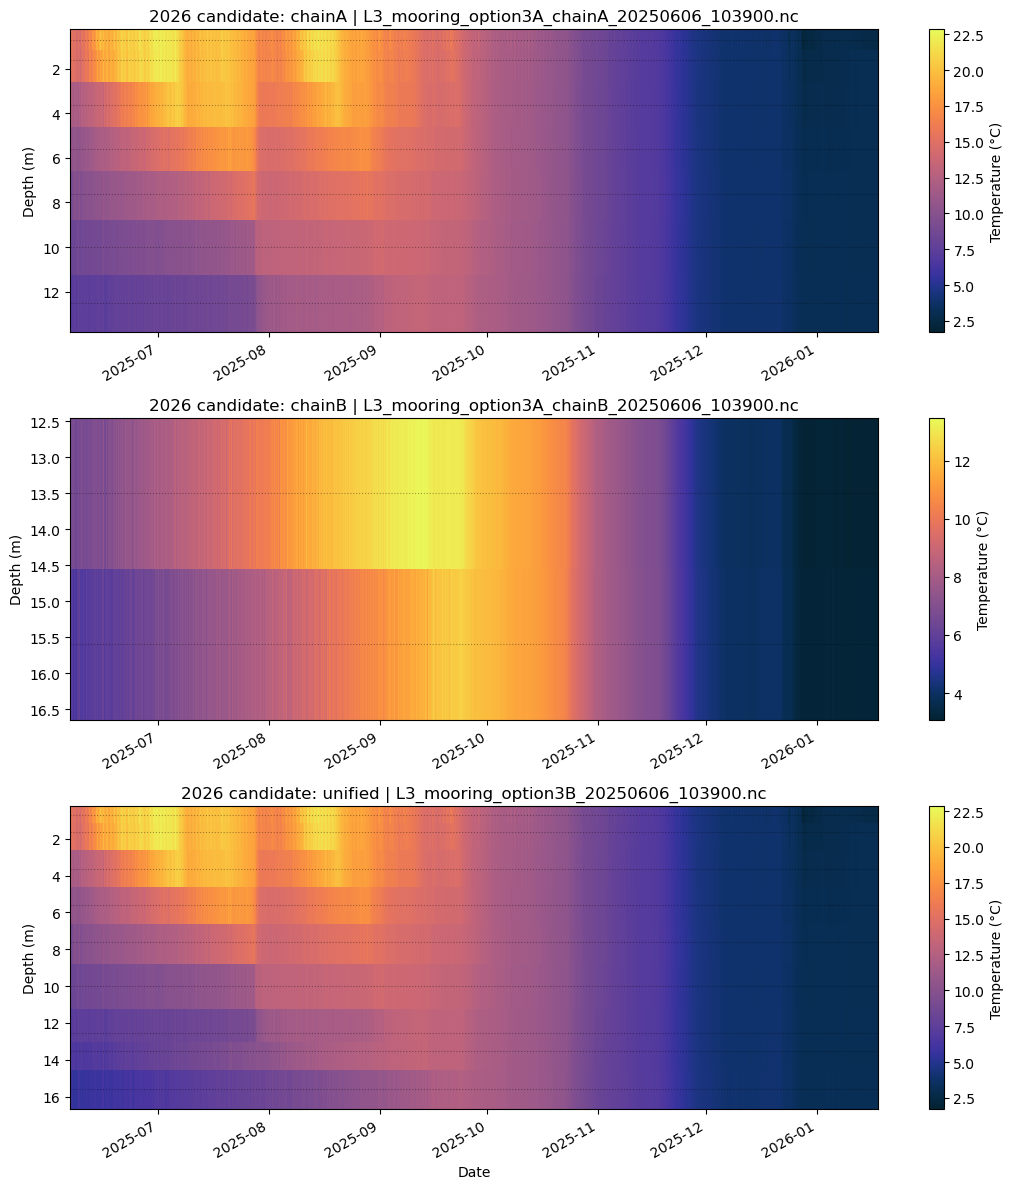

In [77]:
n_candidates = len(records_2026)
fig, axes = plt.subplots(n_candidates, 1, figsize=(11, 4 * n_candidates), sharex=False)

if n_candidates == 1:
    axes = [axes]

for ax, (label, rec) in zip(axes, records_2026.items()):
    temp_masked = np.ma.masked_invalid(rec["temp"])

    hp = ax.pcolormesh(
        rec["time_date"],
        rec["depth"],
        temp_masked,
        shading="auto",
        cmap=cmap_temperature
    )

    for d in rec["depth"]:
        ax.plot(
            [rec["time_date"][0], rec["time_date"][-1]],
            [d, d],
            ":k",
            linewidth=0.8,
            alpha=0.35
        )

    ax.invert_yaxis()
    ax.set_ylabel("Depth (m)")
    ax.set_title("2026 candidate: {} | {}".format(label, rec["file"]))

    cb = plt.colorbar(hp, ax=ax)
    cb.set_label("Temperature (°C)")

axes[-1].set_xlabel("Date")
fig.autofmt_xdate()
fig.tight_layout()

## 7. Diagnostic plot: miniDOT against each 2026 option

The miniDOT temperature is compared with the closest HOBO sensor in each 2026 candidate. The miniDOT is much deeper than the HOBO chain, so the comparison is mainly a sanity check for timing and general behavior, not a strict calibration test.

miniDOT comparison summary:
  chainA | closest HOBO 12.53 m | valid 32507 | bias -4.02 °C | RMSE 5.01 °C | r 0.73
  chainB | closest HOBO 15.60 m | valid 32507 | bias -3.22 °C | RMSE 4.12 °C | r 0.74
  unified | closest HOBO 15.60 m | valid 32507 | bias -3.22 °C | RMSE 4.12 °C | r 0.74


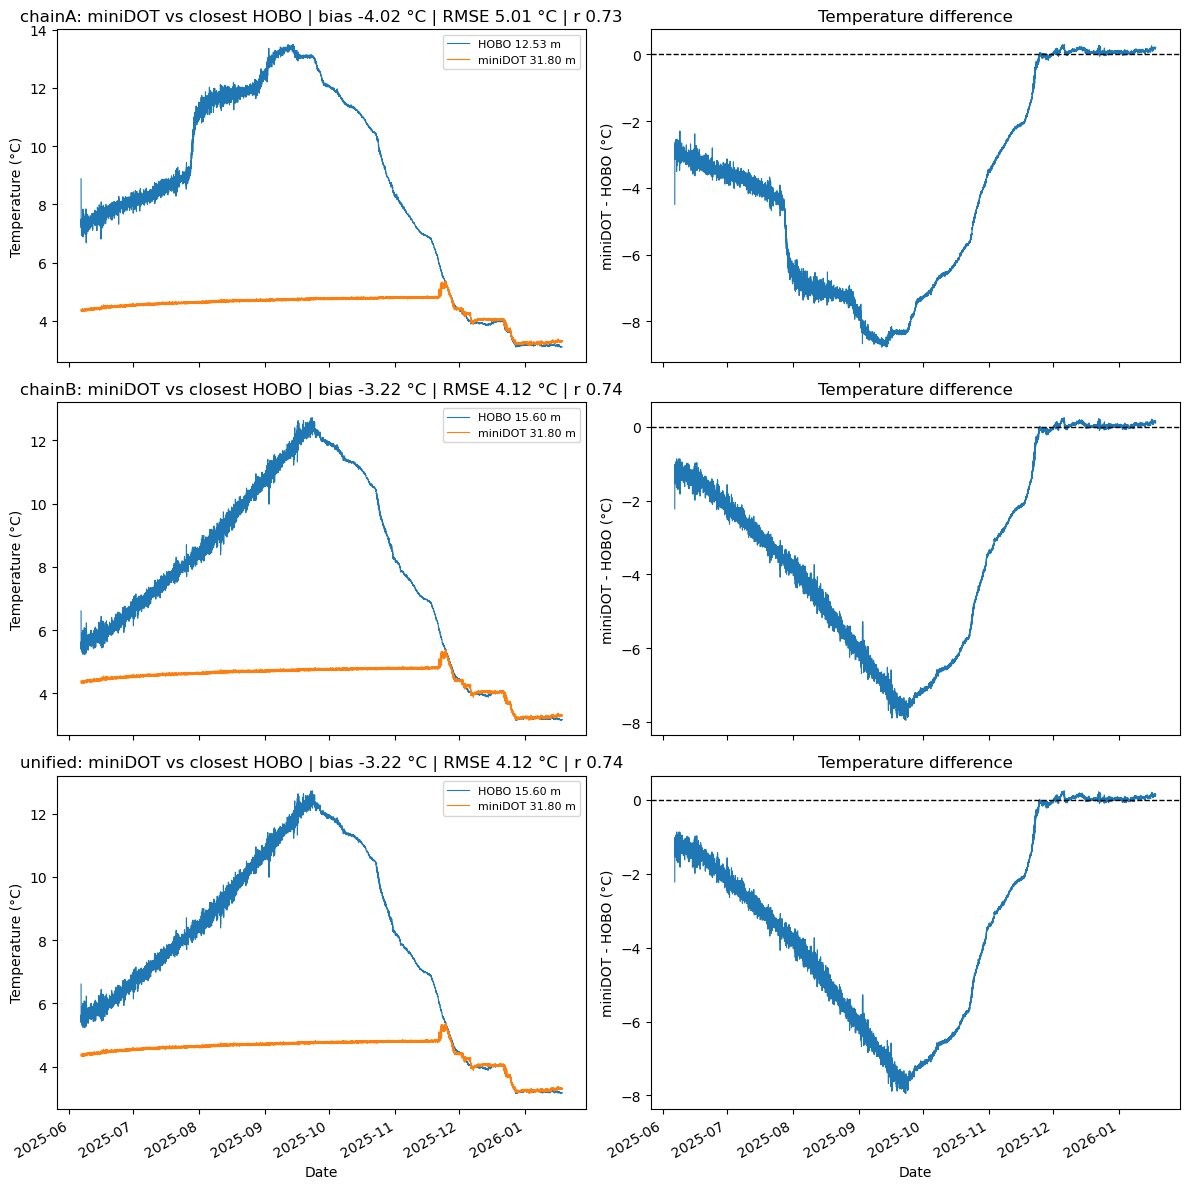

In [78]:
minidot_comparisons = {}

fig, axes = plt.subplots(
    len(records_2026),
    2,
    figsize=(12, 4 * len(records_2026)),
    sharex=False
)

if len(records_2026) == 1:
    axes = np.array([axes])

for row, (label, rec) in enumerate(records_2026.items()):
    hobo_time = rec["time"]
    hobo_dates = rec["time_date"]
    hobo_depths = rec["depth"]
    hobo_temp = rec["temp"]

    closest_idx = np.argmin(np.abs(hobo_depths - minidot_depth))
    closest_depth = hobo_depths[closest_idx]
    closest_temp = hobo_temp[closest_idx, :]

    mini_temp_on_hobo = interp_with_nans(mini_time_num, mini_temp, hobo_time)
    mini_do_on_hobo = interp_with_nans(mini_time_num, mini_do, hobo_time)
    mini_sat_on_hobo = interp_with_nans(mini_time_num, mini_sat, hobo_time)

    valid_compare = ~np.isnan(closest_temp) & ~np.isnan(mini_temp_on_hobo)
    diff_temp = mini_temp_on_hobo - closest_temp

    if np.sum(valid_compare) > 10:
        bias = np.nanmean(diff_temp[valid_compare])
        rmse = np.sqrt(np.nanmean(diff_temp[valid_compare] ** 2))
        corr = np.corrcoef(
            mini_temp_on_hobo[valid_compare],
            closest_temp[valid_compare]
        )[0, 1]
    else:
        bias = np.nan
        rmse = np.nan
        corr = np.nan

    minidot_comparisons[label] = {
        "closest_depth": closest_depth,
        "mini_temp_on_hobo": mini_temp_on_hobo,
        "mini_do_on_hobo": mini_do_on_hobo,
        "mini_sat_on_hobo": mini_sat_on_hobo,
        "diff_temp": diff_temp,
        "bias": bias,
        "rmse": rmse,
        "corr": corr,
        "valid_points": np.sum(valid_compare)
    }

    ax0 = axes[row, 0]
    ax1 = axes[row, 1]

    ax0.plot(hobo_dates, closest_temp, linewidth=0.8, label="HOBO {:.2f} m".format(closest_depth))
    ax0.plot(hobo_dates, mini_temp_on_hobo, linewidth=0.8, label="miniDOT {:.2f} m".format(minidot_depth))
    ax0.set_ylabel("Temperature (°C)")
    ax0.set_title(
        "{}: miniDOT vs closest HOBO | bias {:.2f} °C | RMSE {:.2f} °C | r {:.2f}".format(
            label,
            bias,
            rmse,
            corr
        )
    )
    ax0.legend(fontsize=8)

    ax1.plot(hobo_dates, diff_temp, linewidth=0.8)
    ax1.axhline(0, linestyle="--", color="k", linewidth=1)
    ax1.set_ylabel("miniDOT - HOBO (°C)")
    ax1.set_title("Temperature difference")

axes[-1, 0].set_xlabel("Date")
axes[-1, 1].set_xlabel("Date")
fig.autofmt_xdate()
fig.tight_layout()

print("miniDOT comparison summary:")
for label, comp in minidot_comparisons.items():
    print(
        "  {} | closest HOBO {:.2f} m | valid {} | bias {:.2f} °C | RMSE {:.2f} °C | r {:.2f}".format(
            label,
            comp["closest_depth"],
            comp["valid_points"],
            comp["bias"],
            comp["rmse"],
            comp["corr"]
        )
    )

## 8. Diagnostic plot: miniDOT dissolved oxygen

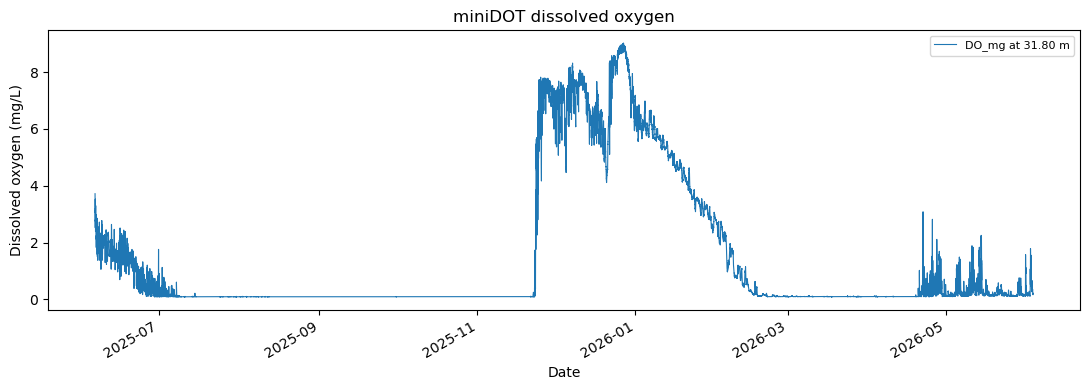

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(11, 4))

ax.plot(
    mini_time_date,
    mini_do,
    linewidth=0.8,
    label="DO_mg at {:.2f} m".format(minidot_depth)
)

ax.set_ylabel("Dissolved oxygen (mg/L)")
ax.set_xlabel("Date")
ax.set_title("miniDOT dissolved oxygen")
ax.legend(fontsize=8)

fig.autofmt_xdate()
fig.tight_layout()

## 9. Analysis choices

Change only this cell when you want to test another analysis version.

- `selected_2026_option`: choose one key from `records_2026.keys()`.
- `use_minidot_as_bottom`: set to `True` only if the miniDOT temperature looks usable.
- `strat_threshold` and `strat_min_hours`: control stratification detection.
- `ice_inverse_threshold`: controls inverse-stratification ice detection.
- `rtrm_dz`: vertical grid spacing used for RTRM.

In [80]:
### Analysis choices

# This is the main control cell for the analysis.
# Run the cleaning cell before this one if you want to remove retrieval artefacts.
#
# After changing any value here, rerun:
#   1) Build the final analysis records
#   2) Rebuild combined grids
#   3) Stratification / ice / RTRM / mixing cells

# ── Choose the 2026 HOBO option ─────────────────────────────────────────────

print("Available 2026 options:", list(records_2026.keys()))

selected_2026_option = "chainA"   # choose "chainA" or "chainB"


# ── Choose whether to add miniDOT temperature as the 2026 bottom sensor ─────

# If True:
#   miniDOT temperature is added as the deep/bottom sensor for 2026.
#
# If False:
#   analyses use only the shared HOBO depth interval.

use_minidot_as_bottom = True


# ── Stratification settings ─────────────────────────────────────────────────

# Stratification starts when the surface-bottom temperature difference
# exceeds this threshold for the selected minimum duration.

strat_threshold = 1.0       # °C
strat_min_hours = 48        # h


# ── Ice-cover settings ──────────────────────────────────────────────────────

# Ice cover is inferred from inverse stratification:
# bottom water warmer than surface water.
#
# Event logic:
#   Ice starts when bottom-surface ΔT >= ice_on_threshold for ice_min_on_hours.
#   Ice ends when bottom-surface ΔT <= ice_off_threshold for ice_min_off_hours.
#
# If ice_off_threshold is lower than ice_on_threshold, short noisy recrossings
# do not split the ice period.

ice_on_threshold = 0.10        # °C, start ice cover
ice_off_threshold = 0.00       # °C, end ice cover
ice_min_on_hours = 48          # h
ice_min_off_hours = 48         # h
keep_only_longest_ice_period = True


# ── Check choices and print status ──────────────────────────────────────────

if selected_2026_option not in records_2026:
    raise ValueError(
        "selected_2026_option must be one of {}".format(list(records_2026.keys()))
    )

analysis_status = (
    "2026 option: {} | miniDOT bottom sensor: {}".format(
        selected_2026_option,
        "YES" if use_minidot_as_bottom else "NO"
    )
)

print(analysis_status)
print("Stratification threshold: ΔT ≥ {:.2f} °C for {} h".format(
    strat_threshold,
    strat_min_hours
))
print("Ice start: bottom-surface ΔT ≥ {:.2f} °C for {} h".format(
    ice_on_threshold,
    ice_min_on_hours
))
print("Ice end: bottom-surface ΔT ≤ {:.2f} °C for {} h".format(
    ice_off_threshold,
    ice_min_off_hours
))
print("Keep only longest ice-cover period:", keep_only_longest_ice_period)


Available 2026 options: ['chainA', 'chainB', 'unified']
2026 option: chainA | miniDOT bottom sensor: YES
Stratification threshold: ΔT ≥ 1.00 °C for 48 h
Ice start: bottom-surface ΔT ≥ 0.10 °C for 48 h
Ice end: bottom-surface ΔT ≤ 0.00 °C for 48 h
Keep only longest ice-cover period: True


## 10. Build the final analysis records

This cell creates `records_for_analysis` from all historical campaigns plus the selected 2026 candidate. If selected, miniDOT temperature is added as an additional 31.8 m sensor to the 2026 profile.

In [81]:
records_for_analysis = copy.deepcopy(historical_records)
selected_record_2026 = copy.deepcopy(records_2026[selected_2026_option])

if use_minidot_as_bottom:
    print("Adding miniDOT temperature as bottom sensor for 2026.")

    mini_temp_on_2026 = interp_with_nans(
        mini_time_num,
        mini_temp,
        selected_record_2026["time"]
    )

    if np.any(np.isclose(selected_record_2026["depth"], minidot_depth)):
        idx_existing = np.where(np.isclose(selected_record_2026["depth"], minidot_depth))[0][0]
        selected_record_2026["temp"][idx_existing, :] = mini_temp_on_2026
    else:
        selected_record_2026["depth"] = np.concatenate((selected_record_2026["depth"], [minidot_depth]))
        selected_record_2026["temp"] = np.vstack((selected_record_2026["temp"], mini_temp_on_2026))

    order = np.argsort(selected_record_2026["depth"])
    selected_record_2026["depth"] = selected_record_2026["depth"][order]
    selected_record_2026["temp"] = selected_record_2026["temp"][order, :]

else:
    print("miniDOT temperature is not added to the 2026 profile.")

records_for_analysis.append(selected_record_2026)

print("\nFinal records for analysis:")
for r in records_for_analysis:
    print(
        "  {} | {} | depths {:.2f}-{:.2f} m | {} depths | {} time steps".format(
            r["camp"],
            r["label"],
            np.nanmin(r["depth"]),
            np.nanmax(r["depth"]),
            len(r["depth"]),
            len(r["time"])
        )
    )

Adding miniDOT temperature as bottom sensor for 2026.

Final records for analysis:
  20240527 | 20240527 | depths 0.00-25.00 m | 10 depths | 10515 time steps
  20240910 | 20240910 | depths 0.00-25.00 m | 9 depths | 15156 time steps
  20241126 | 20241126 | depths 0.00-25.00 m | 10 depths | 11076 time steps
  20250604 | 20250604 | depths 0.00-25.00 m | 10 depths | 5333 time steps
  20260603 | chainA | depths 0.70-31.80 m | 8 depths | 32509 time steps


## 11. Rebuild combined grids

- `temp_grid` uses the full available depth range for plotting.
- `temp_common` uses only the depth interval shared by all selected deployments for comparable metrics.
- `temp_sensors` keeps the original sensor depths for raw time-series plots.

In [82]:
dz_plot = 0.1
dz_common = 0.1

global_min_depth = min(np.nanmin(r["depth"]) for r in records_for_analysis)
global_max_depth = max(np.nanmax(r["depth"]) for r in records_for_analysis)

depth_grid = np.arange(
    global_min_depth,
    global_max_depth + dz_plot / 2,
    dz_plot
)

common_min_depth = max(np.nanmin(r["depth"]) for r in records_for_analysis)
common_max_depth = min(np.nanmax(r["depth"]) for r in records_for_analysis)

depth_common = np.arange(
    common_min_depth,
    common_max_depth + dz_common / 2,
    dz_common
)

if depth_common[-1] > common_max_depth:
    depth_common[-1] = common_max_depth

if not np.isclose(depth_common[-1], common_max_depth):
    depth_common = np.concatenate((depth_common, [common_max_depth]))

print("Full plot depth grid: {:.2f}-{:.2f} m".format(depth_grid[0], depth_grid[-1]))
print("Common analysis depth grid: {:.2f}-{:.2f} m".format(depth_common[0], depth_common[-1]))

# Interpolate all selected deployments onto the two grids.
time_num = np.array([])
temp_grid = np.empty((len(depth_grid), 0))
temp_common = np.empty((len(depth_common), 0))

deployment_info = []

for r in records_for_analysis:
    temp_grid_add = interpolate_profile_to_grid(r["depth"], r["temp"], depth_grid)
    temp_common_add = interpolate_profile_to_grid(r["depth"], r["temp"], depth_common)

    time_num = np.concatenate((time_num, r["time"]))
    temp_grid = np.concatenate((temp_grid, temp_grid_add), axis=1)
    temp_common = np.concatenate((temp_common, temp_common_add), axis=1)

    deployment_info.append({
        "camp": r["camp"],
        "label": r["label"],
        "start_time": r["time"][0],
        "end_time": r["time"][-1],
        "depths": np.sort(r["depth"])
    })

# Sort combined arrays by time.
time_order = np.argsort(time_num)
time_num = time_num[time_order]
temp_grid = temp_grid[:, time_order]
temp_common = temp_common[:, time_order]
time_date = time_num.astype("datetime64[s]").astype(datetime)

# Raw sensor-depth matrix.
depth_sensors = np.unique(
    np.round(
        np.concatenate([r["depth"] for r in records_for_analysis]),
        2
    )
)

temp_sensors = np.full((len(depth_sensors), len(time_num)), np.nan)
time_lookup = {int(round(t)): i for i, t in enumerate(time_num)}

for r in records_for_analysis:
    depth_round = np.round(r["depth"], 2)

    for kt, t in enumerate(r["time"]):
        global_idx = time_lookup.get(int(round(t)))

        if global_idx is None:
            continue

        for kd, d in enumerate(depth_round):
            sensor_idx = np.where(np.isclose(depth_sensors, d))[0]

            if len(sensor_idx) > 0:
                temp_sensors[sensor_idx[0], global_idx] = r["temp"][kd, kt]

common_depth_text = "Common analysis depth: {:.2f}-{:.2f} m".format(depth_common[0], depth_common[-1])
plot_depth_text = "Full plotted depth: {:.2f}-{:.2f} m".format(depth_grid[0], depth_grid[-1])

print("\nUpdated combined dataset:")
print("  time:", time_date[0], "to", time_date[-1])
print("  temp_grid shape:", temp_grid.shape)
print("  temp_common shape:", temp_common.shape)
print("  depth_sensors:")
print(depth_sensors)
print("\n" + analysis_status)
print(common_depth_text)
print(plot_depth_text)

Full plot depth grid: 0.00-31.80 m
Common analysis depth grid: 0.70-25.00 m

Updated combined dataset:
  time: 2024-03-15 12:30:00 to 2026-01-18 04:39:00
  temp_grid shape: (319, 74589)
  temp_common shape: (244, 74589)
  depth_sensors:
[ 0.    0.7   1.62  2.5   3.62  5.    5.62  7.5   7.6  10.   10.01 12.5
 12.53 15.   17.5  20.   25.   31.8 ]

2026 option: chainA | miniDOT bottom sensor: YES
Common analysis depth: 0.70-25.00 m
Full plotted depth: 0.00-31.80 m


## 12. Final plot: raw sensor time series

Background image not found: ../cheese.jpeg


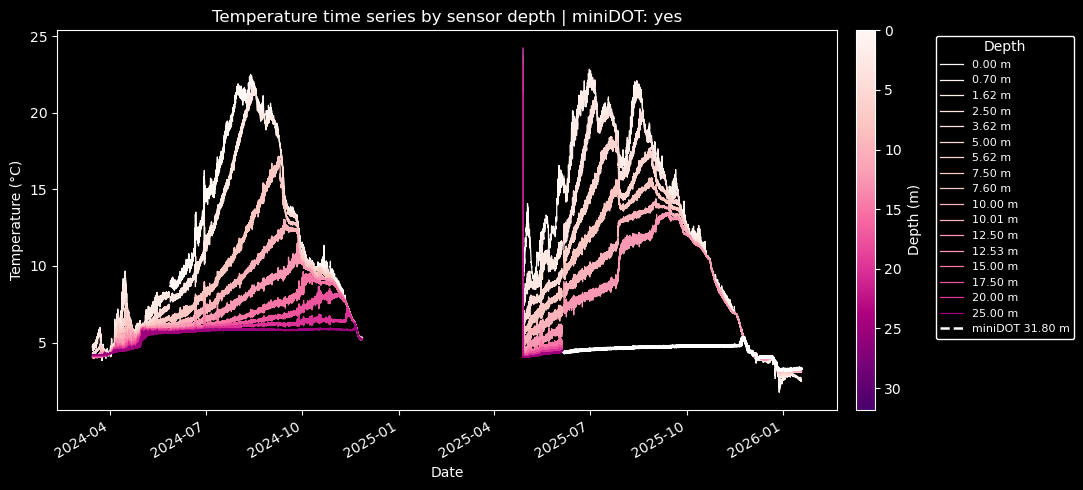

In [83]:
### Temperature time series by sensor depth
### Rose colormap + black background + custom image background

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.image as mpimg

fig1, ax = plt.subplots(1, 1, figsize=(11, 5))

# ── Background style ────────────────────────────────────────────────────────

fig1.patch.set_facecolor("black")
ax.set_facecolor("black")


# ── Rose depth colormap ─────────────────────────────────────────────────────

cmap = plt.get_cmap("RdPu")

norm = mpl.colors.Normalize(
    vmin=np.nanmin(depth_sensors),
    vmax=np.nanmax(depth_sensors)
)


# ── Plot temperature time series ────────────────────────────────────────────

for kd, d in enumerate(depth_sensors):

    y = temp_sensors[kd, :]

    if np.all(np.isnan(y)):
        continue

    line_color = cmap(norm(d))

    is_minidot = (
        use_minidot_as_bottom
        and "minidot_depth" in globals()
        and np.isclose(d, minidot_depth)
    )

    if is_minidot:

        ax.plot(
            time_date,
            y,
            color="white",
            linewidth=1.8,
            linestyle="--",
            label="miniDOT {:.2f} m".format(d),
            zorder=3
        )

    else:

        ax.plot(
            time_date,
            y,
            color=line_color,
            linewidth=0.9,
            label="{:.2f} m".format(d),
            zorder=2
        )


# ── Custom background image ─────────────────────────────────────────────────
# The image is stored at the root of the GitHub repo.
# Since the notebook runs from the notebooks folder, the relative path is ../cheese.jpeg.

background_path = os.path.join("..", "cheese.jpeg")

if os.path.exists(background_path):

    bg = mpimg.imread(background_path)

    # Save current plot limits before adding the image
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    ax.imshow(
        bg,
        extent=[
            xlim[0],
            xlim[1],
            ylim[0],
            ylim[1]
        ],
        aspect="auto",
        alpha=0.50,
        zorder=0
    )

    # Restore limits so the image does not change the plot extent
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

else:

    print("Background image not found:", background_path)


# ── Labels and title ────────────────────────────────────────────────────────

ax.set_ylabel("Temperature (°C)", color="white")
ax.set_xlabel("Date", color="white")

ax.set_title(
    "Temperature time series by sensor depth | "
    f"miniDOT: {'yes' if use_minidot_as_bottom else 'no'}",
    color="white"
)

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

for spine in ax.spines.values():
    spine.set_color("white")


# ── Depth colorbar ──────────────────────────────────────────────────────────

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig1.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Depth (m)", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")
cbar.outline.set_edgecolor("white")
cbar.ax.invert_yaxis()


# ── Legend ──────────────────────────────────────────────────────────────────

leg = ax.legend(
    title="Depth",
    bbox_to_anchor=(1.12, 1),
    loc="upper left",
    fontsize=8,
    facecolor="black",
    edgecolor="white",
    framealpha=1
)

plt.setp(leg.get_texts(), color="white")
plt.setp(leg.get_title(), color="white")


fig1.autofmt_xdate()
fig1.tight_layout()

## 13. Final plot: interpolated temperature grid

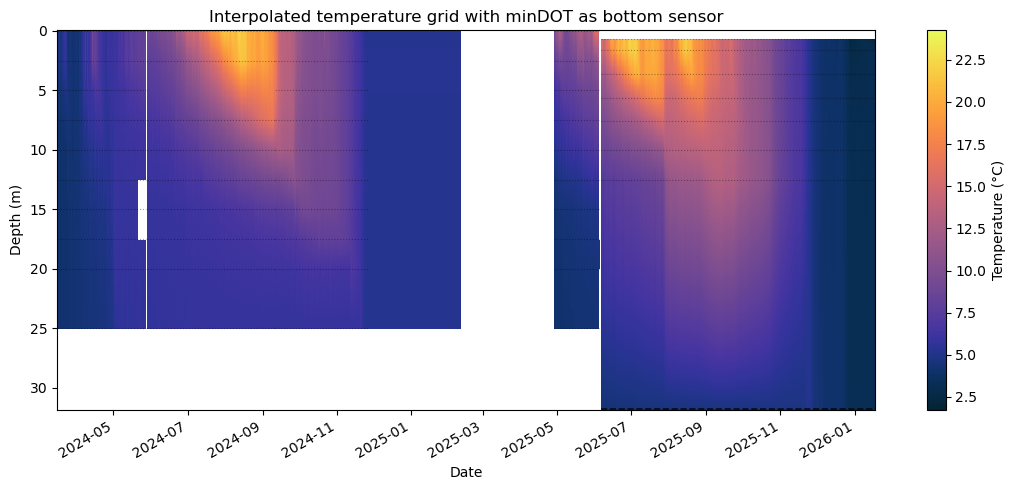

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))

hp = ax.pcolormesh(
    time_date,
    depth_grid,
    temp_grid,
    cmap=cmap_temperature,
    shading="auto"
)

for info in deployment_info:
    start_date = np.datetime64(int(round(info["start_time"])), "s").astype(datetime)
    end_date = np.datetime64(int(round(info["end_time"])), "s").astype(datetime)

    for d in info["depths"]:
        if use_minidot_as_bottom and np.isclose(d, minidot_depth):
            ax.plot([start_date, end_date], [d, d], "--k", linewidth=1.2, alpha=0.8)
        else:
            ax.plot([start_date, end_date], [d, d], ":k", linewidth=0.8, alpha=0.35)

cb = plt.colorbar(hp, ax=ax)
cb.set_label("Temperature (°C)")

ax.invert_yaxis()
ax.set_ylabel("Depth (m)")
ax.set_xlabel("Date")
ax.set_title("Interpolated temperature grid with minDOT as bottom sensor")
    

fig.autofmt_xdate()
fig.tight_layout()

In [85]:
### Metric depth-mode helper

# This cell decides which temperature profile is used for metrics.
#
# If miniDOT is not used:
#   metrics use the fixed common depth interval, depth_common/temp_common.
#
# If miniDOT is used:
#   metrics use all available depths in each deployment, depth_grid/temp_grid.
#   This allows the 2026 campaign to use the miniDOT as the bottom sensor.

def get_surface_bottom_for_metrics():
    """
    Return surface and bottom temperature series for stratification and ice-cover metrics.

    Output:
        T_surface
        T_bottom
        surface_depth_used
        bottom_depth_used
        metric_depth_mode
    """

    n = len(time_num)

    if use_minidot_as_bottom:

        # Check that the miniDOT was really included in the rebuilt grid.
        if "minidot_depth" in globals():
            if np.nanmax(depth_grid) < minidot_depth - 0.1:
                raise ValueError(
                    "use_minidot_as_bottom is True, but depth_grid does not reach the miniDOT depth. "
                    "Rerun the miniDOT addition and rebuild-grid cells."
                )

        T_surface = np.full(n, np.nan)
        T_bottom = np.full(n, np.nan)

        surface_depth_used = np.full(n, np.nan)
        bottom_depth_used = np.full(n, np.nan)

        for kt in range(n):

            ok = np.where(~np.isnan(temp_grid[:, kt]))[0]

            if len(ok) >= 2:

                surface_idx = ok[0]
                bottom_idx = ok[-1]

                T_surface[kt] = temp_grid[surface_idx, kt]
                T_bottom[kt] = temp_grid[bottom_idx, kt]

                surface_depth_used[kt] = depth_grid[surface_idx]
                bottom_depth_used[kt] = depth_grid[bottom_idx]

        metric_depth_mode = "available deployment-specific depths"

    else:

        T_surface = temp_common[0, :]
        T_bottom = temp_common[-1, :]

        surface_depth_used = np.full(n, depth_common[0])
        bottom_depth_used = np.full(n, depth_common[-1])

        metric_depth_mode = "fixed common depth interval"

    return T_surface, T_bottom, surface_depth_used, bottom_depth_used, metric_depth_mode


def apply_persistence(mask, time_num, min_hours, max_gap_factor=3):
    """
    Apply a persistence filter to a boolean mask.
    Large time gaps reset the run.
    """

    dt_sec = np.median(np.diff(time_num))
    nmin = int(round(min_hours * 3600 / dt_sec))

    out = np.zeros(len(mask), dtype=bool)

    run = 0

    for kt in range(len(mask)):

        if kt > 0:
            gap_too_large = (time_num[kt] - time_num[kt - 1]) > max_gap_factor * dt_sec
        else:
            gap_too_large = False

        if gap_too_large:
            run = 0

        if mask[kt]:
            run += 1
        else:
            run = 0

        if run >= nmin:
            out[kt - nmin + 1:kt + 1] = True

    return out


def print_metric_depth_summary(surface_depth_used, bottom_depth_used, metric_depth_mode):
    """
    Print which depths are used by the metric.
    """

    print("Metric depth mode:", metric_depth_mode)

    print(
        "Surface depth range used: {:.2f}-{:.2f} m".format(
            np.nanmin(surface_depth_used),
            np.nanmax(surface_depth_used)
        )
    )

    print(
        "Bottom depth range used: {:.2f}-{:.2f} m".format(
            np.nanmin(bottom_depth_used),
            np.nanmax(bottom_depth_used)
        )
    )

## 14. Stratification period from selected surface-bottom temperature difference


2026 option: chainA | miniDOT bottom sensor: YES
Metric depth mode: available deployment-specific depths
Surface depth range used: 0.00-17.60 m
Bottom depth range used: 20.00-31.80 m
Stratification threshold: ΔT ≥ 1.00 °C
Persistence filter: 48 h
Stratified duration: 413.8 days


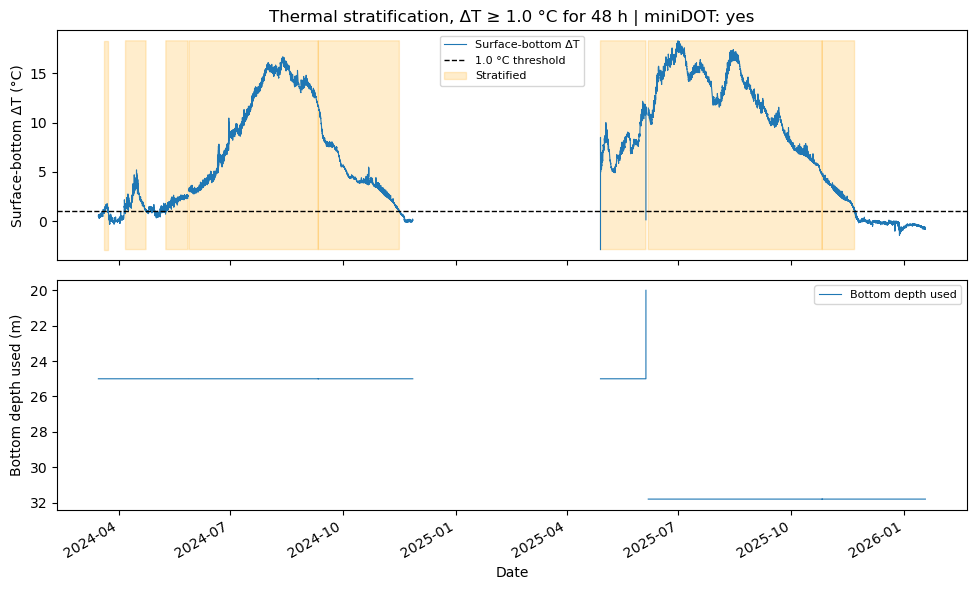

In [86]:
### Stratification period

T_surface, T_bottom, surface_depth_used, bottom_depth_used, metric_depth_mode = get_surface_bottom_for_metrics()

dT_surf_bot = T_surface - T_bottom

strat_raw = np.nan_to_num(dT_surf_bot, nan=-999) >= strat_threshold
stratified = apply_persistence(strat_raw, time_num, strat_min_hours)

dt_sec = np.median(np.diff(time_num))
strat_days = stratified.sum() * dt_sec / 86400

print(analysis_status)
print_metric_depth_summary(surface_depth_used, bottom_depth_used, metric_depth_mode)
print("Stratification threshold: ΔT ≥ {:.2f} °C".format(strat_threshold))
print("Persistence filter: {} h".format(strat_min_hours))
print("Stratified duration: {:.1f} days".format(strat_days))

fig3, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(
    time_date,
    dT_surf_bot,
    linewidth=0.8,
    label="Surface-bottom ΔT"
)

axes[0].axhline(
    strat_threshold,
    linestyle="--",
    color="k",
    linewidth=1,
    label="{:.1f} °C threshold".format(strat_threshold)
)

axes[0].fill_between(
    time_date,
    np.nanmin(dT_surf_bot),
    np.nanmax(dT_surf_bot),
    where=stratified,
    alpha=0.2,
    color="orange",
    label="Stratified"
)

axes[0].set_ylabel("Surface-bottom ΔT (°C)")
axes[0].set_title(
    f"Thermal stratification, ΔT ≥ {strat_threshold:.1f} °C for {strat_min_hours} h | "
    f"miniDOT: {'yes' if use_minidot_as_bottom else 'no'}"
)

axes[0].legend(fontsize=8)

axes[1].plot(
    time_date,
    bottom_depth_used,
    linewidth=0.8,
    label="Bottom depth used"
)

axes[1].invert_yaxis()
axes[1].set_ylabel("Bottom depth used (m)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=8)

fig3.autofmt_xdate()
fig3.tight_layout()

## 15. Inferred ice cover from inverse stratification

This is a simple temperature-based diagnostic. Ice cover is inferred as the longest continuous period where the common-depth bottom temperature is warmer than the near-surface temperature by at least the chosen threshold.

2026 option: chainA | miniDOT bottom sensor: YES
Metric depth mode: available deployment-specific depths
Surface depth range used: 0.00-17.60 m
Bottom depth range used: 20.00-31.80 m
Ice start threshold: bottom-surface ΔT ≥ 0.10 °C for 48 h
Ice end threshold: bottom-surface ΔT ≤ 0.00 °C for 48 h
Total inferred ice-covered duration: 32.54 days

Detected ice-cover period(s):
  Period 1: 2025-12-16 to 2026-01-18  (32.54 days)
Total inferred ice-covered duration: 32.54 days


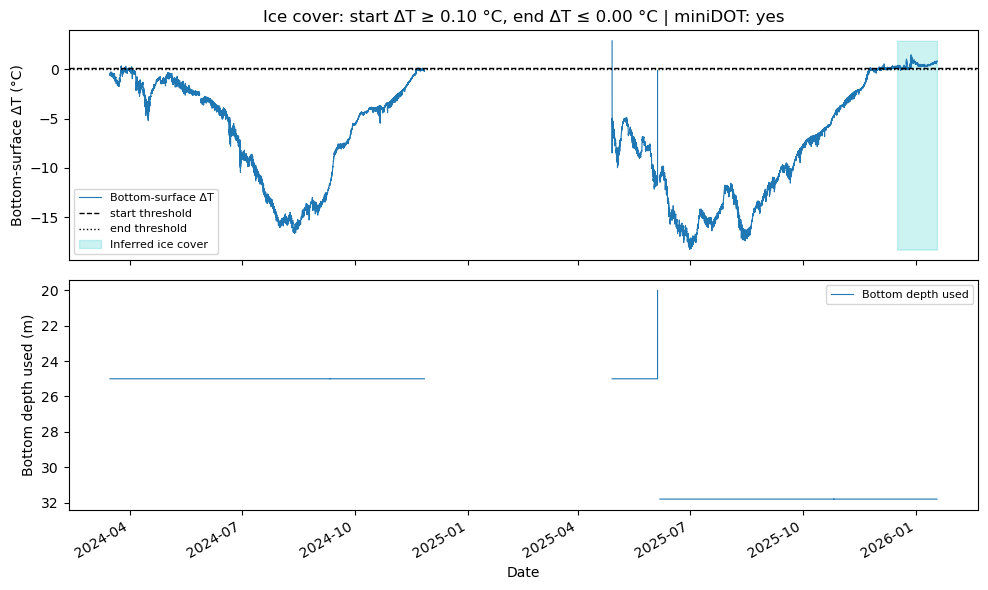

In [87]:
### Ice-cover detection from inverse stratification with start/end thresholds

# Ice cover is inferred from inverse winter stratification:
# bottom water is warmer than surface water.
#
# Event logic:
#   ice starts when bottom-surface ΔT >= ice_on_threshold for ice_min_on_hours
#   ice ends when bottom-surface ΔT <= ice_off_threshold for ice_min_off_hours
#
# The lower off-threshold avoids breaking the ice-cover period because of short noise.
# If you want no hysteresis, set ice_off_threshold = ice_on_threshold.

T_surface, T_bottom, surface_depth_used, bottom_depth_used, metric_depth_mode = get_surface_bottom_for_metrics()

dT_bottom_surface = T_bottom - T_surface

valid_pair = ~np.isnan(T_surface) & ~np.isnan(T_bottom)

ice_on_raw = valid_pair & (dT_bottom_surface >= ice_on_threshold)
ice_off_raw = valid_pair & (dT_bottom_surface <= ice_off_threshold)

dt_sec = np.median(np.diff(time_num))
max_gap_factor = 3

n_on = int(round(ice_min_on_hours * 3600 / dt_sec))
n_off = int(round(ice_min_off_hours * 3600 / dt_sec))


# ── Event detection ─────────────────────────────────────────────────────────

ice_periods = []

in_ice = False
run_on = 0
run_off = 0
ice_start = None

for kt in range(len(time_num)):

    if kt > 0:
        gap_too_large = (time_num[kt] - time_num[kt - 1]) > max_gap_factor * dt_sec
    else:
        gap_too_large = False

    # A large data gap closes the current event at the previous time step.
    if gap_too_large:

        if in_ice and ice_start is not None:
            ice_end = kt - 1
            ice_periods.append((ice_start, ice_end))

        in_ice = False
        run_on = 0
        run_off = 0
        ice_start = None


    if not in_ice:

        # Before ice cover:
        # wait until inverse stratification is sustained long enough.

        if ice_on_raw[kt]:
            run_on += 1
        else:
            run_on = 0

        if run_on >= n_on:
            ice_start = kt - n_on + 1
            in_ice = True
            run_off = 0


    else:

        # During ice cover:
        # keep the event until the off-threshold is recrossed for long enough.

        if ice_off_raw[kt]:
            run_off += 1
        else:
            run_off = 0

        if run_off >= n_off:

            off_start = kt - n_off + 1
            ice_end = off_start - 1

            if ice_end >= ice_start:
                ice_periods.append((ice_start, ice_end))

            in_ice = False
            run_on = 0
            run_off = 0
            ice_start = None


# If the time series ends while still in an ice event, close it at the last time step.
if in_ice and ice_start is not None:
    ice_periods.append((ice_start, len(time_num) - 1))


# ── Optionally keep only the longest ice-cover period ───────────────────────

if keep_only_longest_ice_period and len(ice_periods) > 1:

    durations = [
        end - start + 1
        for start, end in ice_periods
    ]

    longest_idx = np.argmax(durations)
    ice_periods = [ice_periods[longest_idx]]


# ── Create final ice-cover mask ─────────────────────────────────────────────

ice = np.zeros(len(time_num), dtype=bool)

for ice_start, ice_end in ice_periods:
    ice[ice_start:ice_end + 1] = True

ice_days = ice.sum() * dt_sec / 86400


# ── Print summary ───────────────────────────────────────────────────────────

print(analysis_status)
print_metric_depth_summary(surface_depth_used, bottom_depth_used, metric_depth_mode)

print("Ice start threshold: bottom-surface ΔT ≥ {:.2f} °C for {} h".format(
    ice_on_threshold,
    ice_min_on_hours
))

print("Ice end threshold: bottom-surface ΔT ≤ {:.2f} °C for {} h".format(
    ice_off_threshold,
    ice_min_off_hours
))

print("Total inferred ice-covered duration: {:.2f} days".format(ice_days))

if len(ice_periods) > 0:

    print("\nDetected ice-cover period(s):")

    for i, (ice_start, ice_end) in enumerate(ice_periods, start=1):

        dur_days = (ice_end - ice_start + 1) * dt_sec / 86400

        print(
            "  Period {}: {} to {}  ({:.2f} days)".format(
                i,
                time_date[ice_start].date(),
                time_date[ice_end].date(),
                dur_days
            )
        )

else:

    print("No sustained ice-cover period detected.")


# ── Plot ice-cover diagnostic ───────────────────────────────────────────────

fig_ice, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(
    time_date,
    dT_bottom_surface,
    linewidth=0.8,
    label="Bottom-surface ΔT"
)

axes[0].axhline(
    ice_on_threshold,
    linestyle="--",
    color="k",
    linewidth=1,
    label="start threshold"
)

axes[0].axhline(
    ice_off_threshold,
    linestyle=":",
    color="k",
    linewidth=1,
    label="end threshold"
)

if ice.any():

    axes[0].fill_between(
        time_date,
        np.nanmin(dT_bottom_surface),
        np.nanmax(dT_bottom_surface),
        where=ice,
        alpha=0.2,
        color="c",
        label="Inferred ice cover"
    )

axes[0].set_ylabel("Bottom-surface ΔT (°C)")
axes[0].set_title(
    f"Ice cover: start ΔT ≥ {ice_on_threshold:.2f} °C, end ΔT ≤ {ice_off_threshold:.2f} °C | "
    f"miniDOT: {'yes' if use_minidot_as_bottom else 'no'}"
)

axes[0].legend(fontsize=8)


axes[1].plot(
    time_date,
    bottom_depth_used,
    linewidth=0.8,
    label="Bottom depth used"
)

axes[1].invert_yaxis()
axes[1].set_ylabel("Bottom depth used (m)")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=8)

fig_ice.autofmt_xdate()
fig_ice.tight_layout()
print("Total inferred ice-covered duration: {:.2f} days".format(ice_days))

## 16. Top-bottom relative thermal resistance to mixing, RTRM


2026 option: chainA | miniDOT bottom sensor: YES
RTRM depth mode: available deployment-specific depths
Metric depth mode: available deployment-specific depths
Surface depth range used: 0.00-17.60 m
Bottom depth range used: 20.00-31.80 m

Top-bottom RTRM summary:
Maximum RTRM: 291.56 on 2025-06-30
Minimum RTRM: -82.74 on 2025-04-28
Median RTRM: 46.49
Mean RTRM: 82.23


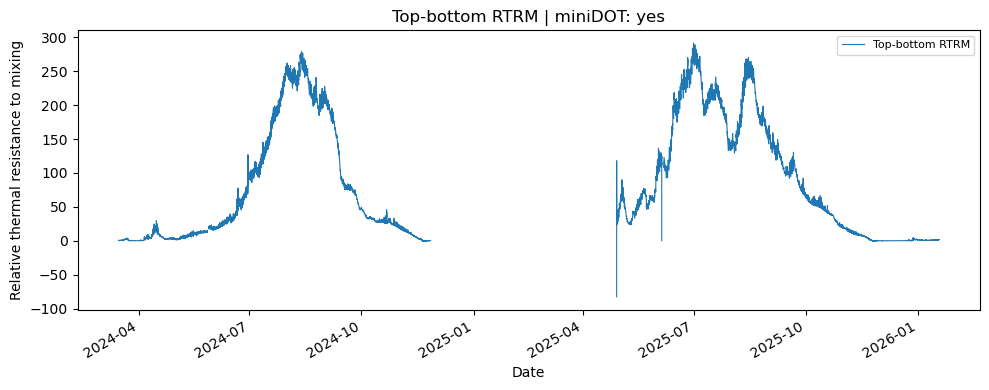

In [88]:
### Probably redundant with temp diff Top-bottom Relative Thermal Resistance to Mixing, RTRM

# This cell calculates a simple top-bottom RTRM time series.
#
# It does NOT calculate layer-wise RTRM.
# The goal here is to keep the output easy to read:
#
#   RTRM = (rho_bottom - rho_surface) / (rho_4C - rho_5C)
#
# where:
#   rho_surface = water density at the surface depth used by the metric
#   rho_bottom  = water density at the bottom depth used by the metric
#   rho_4C      = density of freshwater at 4 °C
#   rho_5C      = density of freshwater at 5 °C
#
# Interpretation:
#   RTRM > 0  : bottom water is denser than surface water.
#               This is stable summer stratification.
#
#   RTRM ≈ 0  : weak density difference between surface and bottom.
#               This suggests weak stratification or mixing.
#
#   RTRM < 0  : inverse density structure.
#               This can occur during cold winter conditions.
#
# Depth choice:
#   If use_minidot_as_bottom = False:
#       RTRM is calculated over the fixed common depth interval.
#
#   If use_minidot_as_bottom = True:
#       RTRM uses the available bottom depth at each time step.
#       During 2026, this can include the miniDOT bottom temperature.

T_surface_rtrm, T_bottom_rtrm, surface_depth_used, bottom_depth_used, metric_depth_mode = get_surface_bottom_for_metrics()

rho_surface = water_density(T_surface_rtrm)
rho_bottom = water_density(T_bottom_rtrm)

rho_4 = water_density(4.0)
rho_5 = water_density(5.0)
rho_ref = rho_4 - rho_5

RTRM_top_bottom = (rho_bottom - rho_surface) / rho_ref

valid_rtrm = np.isfinite(RTRM_top_bottom)

print(analysis_status)
print("RTRM depth mode:", metric_depth_mode)
print_metric_depth_summary(surface_depth_used, bottom_depth_used, metric_depth_mode)

if np.any(valid_rtrm):

    max_idx = np.nanargmax(RTRM_top_bottom)
    min_idx = np.nanargmin(RTRM_top_bottom)

    print("\nTop-bottom RTRM summary:")
    print("Maximum RTRM: {:.2f} on {}".format(
        RTRM_top_bottom[max_idx],
        time_date[max_idx].date()
    ))
    print("Minimum RTRM: {:.2f} on {}".format(
        RTRM_top_bottom[min_idx],
        time_date[min_idx].date()
    ))
    print("Median RTRM: {:.2f}".format(np.nanmedian(RTRM_top_bottom)))
    print("Mean RTRM: {:.2f}".format(np.nanmean(RTRM_top_bottom)))

else:

    print("No valid RTRM values found.")


# ── Plot top-bottom RTRM ────────────────────────────────────────────────────

fig_rtrm, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(
    time_date,
    RTRM_top_bottom,
    linewidth=0.8,
    label="Top-bottom RTRM"
)


ax.set_ylabel("Relative thermal resistance to mixing")
ax.set_xlabel("Date")
ax.set_title(
    f"Top-bottom RTRM | miniDOT: {'yes' if use_minidot_as_bottom else 'no'}"
)
ax.legend(fontsize=8)

fig_rtrm.autofmt_xdate()
fig_rtrm.tight_layout()


## 16b. Mixing periods (autumn and spring overturn)

Reconstructed cell: detects open-water mixing periods that bracket the stratified and ice-covered periods, and builds the masks used by the seasonal-states plot. **Validate the mixing definition with Quentin before using the results.**

In [89]:
### Mixing periods (autumn and spring overturn)
#
# NOTE: this cell was MISSING from the notebook and has been reconstructed from
# the structure expected downstream (the seasonal-states plot and the export
# cell). The bracketing below is the standard dimictic-lake definition; please
# validate it with Quentin before relying on the results.
#
#   strat_periods : continuous runs where `stratified` is True        (start, end)
#   ice_periods   : already built in the ice-cover cell               (start, end)
#   autumn_mixing : open water between the END of a stratified period and the
#                   START of the following ice period
#                   -> (mix_start, mix_end, strat_end, ice_start)
#   spring_mixing : open water between the END of an ice period and the START
#                   of the following stratified period
#                   -> (mix_start, mix_end, ice_end, strat_start)


def period_duration_days(start, end, time_num):
    """Duration in days between two time indices."""
    return (time_num[end] - time_num[start]) / 86400.0


def _gaps_between(end_periods, start_periods):
    """
    For each period in end_periods, find the next period in start_periods that
    begins after it, and return the open-water gap between the two as
    (gap_start, gap_end, end_of_first, start_of_second).
    """
    starts_sorted = sorted(start_periods, key=lambda p: p[0])
    gaps = []

    for a_start, a_end in end_periods:
        following = next((p for p in starts_sorted if p[0] > a_end), None)

        if following is None:
            continue

        b_start = following[0]
        gap_start = a_end + 1
        gap_end = b_start - 1

        if gap_start <= gap_end:
            gaps.append((gap_start, gap_end, a_end, b_start))

    return gaps


# Stratified periods as (start, end) index pairs.
strat_periods = [
    (start, end)
    for start, end, _length in find_continuous_runs(stratified, time_num)
]

# ice_periods comes from the ice-cover cell and is already (start, end).

autumn_mixing = _gaps_between(strat_periods, ice_periods)   # stratification -> ice
spring_mixing = _gaps_between(ice_periods, strat_periods)   # ice -> stratification


# Boolean masks over the full time axis, used by the seasonal-states plot.
autumn_mixing_mask = np.zeros(len(time_num), dtype=bool)
for mix_start, mix_end, _strat_end, _ice_start in autumn_mixing:
    autumn_mixing_mask[mix_start:mix_end + 1] = True

spring_mixing_mask = np.zeros(len(time_num), dtype=bool)
for mix_start, mix_end, _ice_end, _strat_start in spring_mixing:
    spring_mixing_mask[mix_start:mix_end + 1] = True


print("Stratified periods:", len(strat_periods))
print("Ice-cover periods:", len(ice_periods))
print("Autumn mixing periods:", len(autumn_mixing))
print("Spring mixing periods:", len(spring_mixing))

for mix_start, mix_end, _se, _is in autumn_mixing:
    print("  Autumn mixing: {} to {} ({:.1f} days)".format(
        time_date[mix_start].date(),
        time_date[mix_end].date(),
        period_duration_days(mix_start, mix_end, time_num)
    ))

for mix_start, mix_end, _ie, _ss in spring_mixing:
    print("  Spring mixing: {} to {} ({:.1f} days)".format(
        time_date[mix_start].date(),
        time_date[mix_end].date(),
        period_duration_days(mix_start, mix_end, time_num)
    ))


Stratified periods: 8
Ice-cover periods: 1
Autumn mixing periods: 8
Spring mixing periods: 0
  Autumn mixing: 2024-03-23 to 2025-12-16 (633.5 days)
  Autumn mixing: 2024-04-23 to 2025-12-16 (602.3 days)
  Autumn mixing: 2024-05-28 to 2025-12-16 (567.2 days)
  Autumn mixing: 2024-09-10 to 2025-12-16 (461.9 days)
  Autumn mixing: 2024-11-15 to 2025-12-16 (396.0 days)
  Autumn mixing: 2025-06-04 to 2025-12-16 (195.1 days)
  Autumn mixing: 2025-10-26 to 2025-12-16 (51.5 days)
  Autumn mixing: 2025-11-21 to 2025-12-16 (25.2 days)



Summary table of detected periods:


,period_type,period_number,start_date,end_date,duration_days
0,Stratified,1,2024-03-20,2024-03-23,2.8
1,Stratified,2,2024-04-06,2024-04-23,16.7
2,Stratified,3,2024-05-09,2024-05-27,18.1
3,Stratified,4,2024-05-28,2024-09-10,105.2
4,Stratified,5,2024-09-10,2024-11-15,66.0
5,Stratified,6,2025-04-28,2025-06-04,37.0
6,Stratified,7,2025-06-06,2025-10-26,141.7
7,Stratified,8,2025-10-26,2025-11-21,26.4
8,Ice cover,1,2025-12-16,2026-01-18,32.5
9,Autumn mixing,1,2024-03-23,2025-12-16,633.5


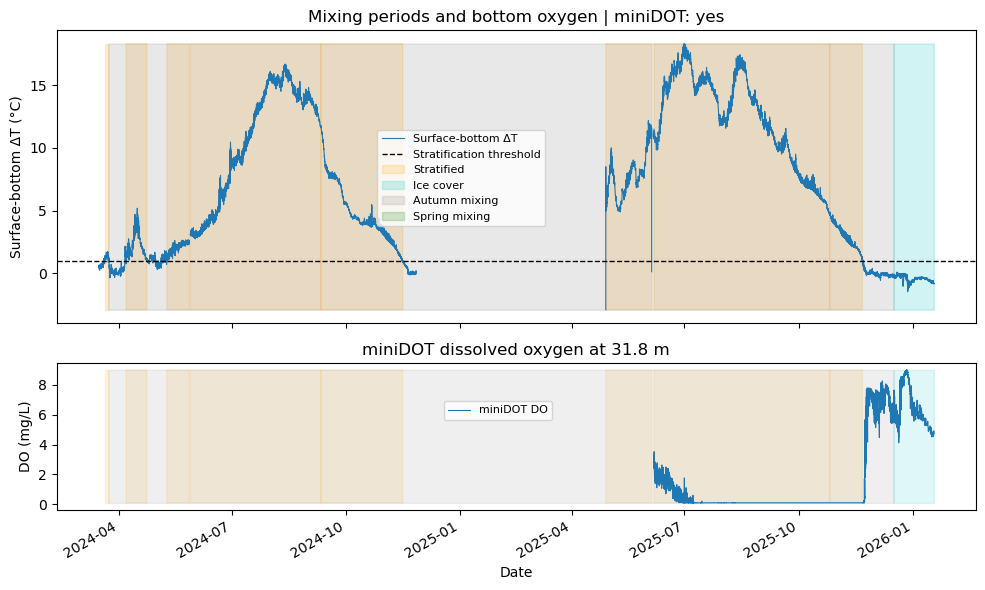

In [90]:
# ── Plot seasonal thermal states + miniDOT DO ───────────────────────────────

# Interpolate miniDOT DO onto the main time axis, if miniDOT data were loaded.
do_on_time = np.full(len(time_num), np.nan)

if "mini_time_num" in globals() and "mini_do" in globals():

    valid_do = np.isfinite(mini_time_num) & np.isfinite(mini_do)

    if np.sum(valid_do) >= 2:

        x_do = mini_time_num[valid_do]
        y_do = mini_do[valid_do]

        order = np.argsort(x_do)
        x_do = x_do[order]
        y_do = y_do[order]

        inside = (time_num >= x_do[0]) & (time_num <= x_do[-1])

        do_on_time[inside] = np.interp(
            time_num[inside],
            x_do,
            y_do
        )

    else:
        print("miniDOT DO exists, but not enough valid values to interpolate.")

else:
    print("miniDOT DO variables not found. Run the miniDOT loading cell first.")


fig_mix, axes = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)


# ── Top panel: thermal states ───────────────────────────────────────────────

ax = axes[0]

ax.plot(
    time_date,
    dT_surf_bot,
    linewidth=0.8,
    label="Surface-bottom ΔT"
)

ax.axhline(
    strat_threshold,
    linestyle="--",
    color="k",
    linewidth=1,
    label="Stratification threshold"
)

ymin = np.nanmin(dT_surf_bot)
ymax = np.nanmax(dT_surf_bot)

ax.fill_between(
    time_date,
    ymin,
    ymax,
    where=stratified,
    alpha=0.18,
    color="orange",
    label="Stratified"
)

ax.fill_between(
    time_date,
    ymin,
    ymax,
    where=ice,
    alpha=0.18,
    color="c",
    label="Ice cover"
)

ax.fill_between(
    time_date,
    ymin,
    ymax,
    where=autumn_mixing_mask,
    alpha=0.18,
    color="grey",
    label="Autumn mixing"
)

ax.fill_between(
    time_date,
    ymin,
    ymax,
    where=spring_mixing_mask,
    alpha=0.18,
    color="green",
    label="Spring mixing"
)

ax.set_ylabel("Surface-bottom ΔT (°C)")
ax.set_title(
    "Mixing periods and bottom oxygen | "
    f"miniDOT: {'yes' if use_minidot_as_bottom else 'no'}"
)

# Legend moved slightly left.
# Decrease the first value to move it further left.
# Increase/decrease the second value to move it up/down.
ax.legend(
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.44, 0.68)
)


# ── Bottom panel: miniDOT dissolved oxygen ──────────────────────────────────

ax = axes[1]

ax.plot(
    time_date,
    do_on_time,
    linewidth=0.8,
    label="miniDOT DO"
)

if np.any(np.isfinite(do_on_time)):

    ymin_do = np.nanmin(do_on_time)
    ymax_do = np.nanmax(do_on_time)

    ax.fill_between(
        time_date,
        ymin_do,
        ymax_do,
        where=stratified,
        alpha=0.12,
        color="orange"
    )

    ax.fill_between(
        time_date,
        ymin_do,
        ymax_do,
        where=ice,
        alpha=0.12,
        color="c"
    )

    ax.fill_between(
        time_date,
        ymin_do,
        ymax_do,
        where=autumn_mixing_mask,
        alpha=0.12,
        color="grey"
    )

    ax.fill_between(
        time_date,
        ymin_do,
        ymax_do,
        where=spring_mixing_mask,
        alpha=0.12,
        color="green"
    )

else:

    ax.text(
        0.5,
        0.5,
        "No miniDOT DO available",
        ha="center",
        va="center",
        transform=ax.transAxes
    )

ax.set_ylabel("DO (mg/L)")
ax.set_xlabel("Date")

if "minidot_depth" in globals():
    ax.set_title(f"miniDOT dissolved oxygen at {minidot_depth:.1f} m")
else:
    ax.set_title("miniDOT dissolved oxygen")

ax.legend(
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.48, 0.78)
)

fig_mix.autofmt_xdate()
fig_mix.tight_layout()
# ── Summary table of period start/end dates ─────────────────────────────────

import pandas as pd

period_rows = []

# Stratified periods
for i, (start, end) in enumerate(strat_periods, start=1):
    period_rows.append({
        "period_type": "Stratified",
        "period_number": i,
        "start_date": time_date[start].strftime("%Y-%m-%d"),
        "end_date": time_date[end].strftime("%Y-%m-%d"),
        "duration_days": period_duration_days(start, end, time_num)
    })

# Ice-covered periods
for i, (start, end) in enumerate(ice_periods, start=1):
    period_rows.append({
        "period_type": "Ice cover",
        "period_number": i,
        "start_date": time_date[start].strftime("%Y-%m-%d"),
        "end_date": time_date[end].strftime("%Y-%m-%d"),
        "duration_days": period_duration_days(start, end, time_num)
    })

# Autumn mixing periods
for i, (mix_start, mix_end, strat_end, ice_start) in enumerate(autumn_mixing, start=1):
    period_rows.append({
        "period_type": "Autumn mixing",
        "period_number": i,
        "start_date": time_date[mix_start].strftime("%Y-%m-%d"),
        "end_date": time_date[mix_end].strftime("%Y-%m-%d"),
        "duration_days": period_duration_days(mix_start, mix_end, time_num)
    })

# Spring mixing periods
for i, (mix_start, mix_end, ice_end, strat_start) in enumerate(spring_mixing, start=1):
    period_rows.append({
        "period_type": "Spring mixing",
        "period_number": i,
        "start_date": time_date[mix_start].strftime("%Y-%m-%d"),
        "end_date": time_date[mix_end].strftime("%Y-%m-%d"),
        "duration_days": period_duration_days(mix_start, mix_end, time_num)
    })

period_table = pd.DataFrame(period_rows)

if len(period_table) > 0:

    period_table["duration_days"] = period_table["duration_days"].round(1)

    print("\nSummary table of detected periods:")
    display(period_table)

else:

    print("\nNo periods detected, so no summary table was created.")

## 17. Optional: export a compact summary table

In [91]:
summary = {
    "selected_2026_option": selected_2026_option,
    "use_minidot_as_bottom": use_minidot_as_bottom,
    "common_surface_depth_m": depth_common[0],
    "common_bottom_depth_m": depth_common[-1],
    "strat_threshold_degC": strat_threshold,
    "strat_min_hours": strat_min_hours,
    "stratified_days": strat_days,
    "ice_on_threshold_degC": ice_on_threshold,
    "ice_off_threshold_degC": ice_off_threshold,
    "ice_min_on_hours": ice_min_on_hours,
    "ice_min_off_hours": ice_min_off_hours,
    "ice_days": ice_days,
    "max_top_bottom_RTRM": np.nanmax(RTRM_top_bottom),
    "median_top_bottom_RTRM": np.nanmedian(RTRM_top_bottom),
    "mean_top_bottom_RTRM": np.nanmean(RTRM_top_bottom),
}

summary_df = pd.DataFrame([summary])
summary_df


,selected_2026_option,use_minidot_as_bottom,common_surface_depth_m,common_bottom_depth_m,strat_threshold_degC,strat_min_hours,stratified_days,ice_on_threshold_degC,ice_off_threshold_degC,ice_min_on_hours,ice_min_off_hours,ice_days,max_top_bottom_RTRM,median_top_bottom_RTRM,mean_top_bottom_RTRM
0,chainA,True,0.7,25.0,1.0,48,413.840278,0.1,0.0,48,48,32.541667,291.560789,46.489865,82.234343


In [92]:
### Export all figures to a figures folder

# This cell saves the figures generated in the notebook.
# Run it after running all plotting cells.
#
# Output folder:
#   ../figures/mooring_analysis
#
# You can change output_folder if you want another location.


# ── User settings ───────────────────────────────────────────────────────────

output_folder = os.path.join("..", "figures", "mooring_analysis")

export_png = True
export_pdf = True

dpi = 300

os.makedirs(output_folder, exist_ok=True)


# ── Named figures to export ─────────────────────────────────────────────────

# The notebook may not always generate all figures, depending on choices.
# Therefore, each figure is exported only if it exists.

figure_map = {
    "01_sensor_time_series": "fig1",
    "02_temperature_grid": "fig2",
    "03_stratification_period": "fig3",
    "04_ice_cover": "fig_ice",
    "05_top_bottom_RTRM": "fig_rtrm",
    "06_mixing_periods_and_DO": "fig_mix",
    "07_minidot_comparison": "fig_md"
}

exported = []

for filename_base, fig_var_name in figure_map.items():

    if fig_var_name in globals():

        fig = globals()[fig_var_name]

        if export_png:
            png_path = os.path.join(output_folder, filename_base + ".png")
            fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
            exported.append(png_path)

        if export_pdf:
            pdf_path = os.path.join(output_folder, filename_base + ".pdf")
            fig.savefig(pdf_path, bbox_inches="tight")
            exported.append(pdf_path)


# ── Export any other currently open figures not listed above ────────────────

# This catches extra diagnostic plots.
# They are saved with generic names.

named_fig_ids = []

for fig_var_name in figure_map.values():
    if fig_var_name in globals():
        named_fig_ids.append(id(globals()[fig_var_name]))

extra_counter = 1

for num in plt.get_fignums():

    fig = plt.figure(num)

    if id(fig) in named_fig_ids:
        continue

    filename_base = "extra_figure_{:02d}".format(extra_counter)

    if export_png:
        png_path = os.path.join(output_folder, filename_base + ".png")
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
        exported.append(png_path)

    if export_pdf:
        pdf_path = os.path.join(output_folder, filename_base + ".pdf")
        fig.savefig(pdf_path, bbox_inches="tight")
        exported.append(pdf_path)

    extra_counter += 1


# ── Write a small metadata file ─────────────────────────────────────────────

metadata_path = os.path.join(output_folder, "analysis_settings.txt")

with open(metadata_path, "w", encoding="utf-8") as f:

    f.write("Mooring analysis figure export\n")
    f.write("==============================\n\n")

    if "analysis_status" in globals():
        f.write("Analysis status: {}\n".format(analysis_status))

    if "selected_2026_option" in globals():
        f.write("Selected 2026 option: {}\n".format(selected_2026_option))

    if "use_minidot_as_bottom" in globals():
        f.write("miniDOT used as bottom sensor: {}\n".format(use_minidot_as_bottom))

    if "retrieval_cutoff_2026" in globals():
        f.write("Retrieval cutoff 2026: {}\n".format(retrieval_cutoff_2026))

    if "strat_threshold" in globals():
        f.write("Stratification threshold: {:.2f} °C\n".format(strat_threshold))

    if "strat_min_hours" in globals():
        f.write("Stratification minimum duration: {} h\n".format(strat_min_hours))

    if "ice_on_threshold" in globals():
        f.write("Ice-on threshold: {:.2f} °C\n".format(ice_on_threshold))

    if "ice_off_threshold" in globals():
        f.write("Ice-off threshold: {:.2f} °C\n".format(ice_off_threshold))

    if "rtrm_dz" in globals():
        f.write("RTRM vertical spacing: {:.2f} m\n".format(rtrm_dz))


print("Figures exported to:")
print(os.path.abspath(output_folder))

print("\nExported files:")
for path in exported:
    print("  " + path)

print("\nMetadata file:")
print("  " + metadata_path)

Figures exported to:
/Users/estelle/Documents/GitHub/taney-monitoring-masterfieldcamp/figures/mooring_analysis

Exported files:
  ../figures/mooring_analysis/01_sensor_time_series.png
  ../figures/mooring_analysis/01_sensor_time_series.pdf
  ../figures/mooring_analysis/03_stratification_period.png
  ../figures/mooring_analysis/03_stratification_period.pdf
  ../figures/mooring_analysis/04_ice_cover.png
  ../figures/mooring_analysis/04_ice_cover.pdf
  ../figures/mooring_analysis/05_top_bottom_RTRM.png
  ../figures/mooring_analysis/05_top_bottom_RTRM.pdf
  ../figures/mooring_analysis/06_mixing_periods_and_DO.png
  ../figures/mooring_analysis/06_mixing_periods_and_DO.pdf

Metadata file:
  ../figures/mooring_analysis/analysis_settings.txt


Weather file loaded:
../data/Meteo/Additional/Weather_data_20260521_clean_outdoor.csv

Raw columns:
0 : timestamp_unix_s
1 : datetime_local
2 : datetime_iso
3 : T_inside_C
4 : RH_inside_pct
5 : CO2_ppm
6 : noise_dB
7 : pressure_hPa
8 : wind_dir_deg
9 : U_kmh
10 : U10_m_s
11 : gust_kmh
12 : gust_dir_deg
13 : Tair_C

First rows:


,timestamp_unix_s,datetime_local,datetime_iso,T_inside_C,RH_inside_pct,CO2_ppm,noise_dB,pressure_hPa,wind_dir_deg,U_kmh,U10_m_s,gust_kmh,gust_dir_deg,Tair_C
0,1727776800,01.10.2024 12:00,01.10.2024 12:00,21.0,46,578,49,1014.7,222,4,1.111111,27,216,8.9
1,1727863200,02.10.2024 12:00,02.10.2024 12:00,21.4,50,765,44,1009.4,222,6,1.666667,36,300,7.2
2,1727949600,03.10.2024 12:00,03.10.2024 12:00,23.1,49,874,47,1008.6,219,4,1.111111,14,171,5.0
3,1728036000,04.10.2024 12:00,04.10.2024 12:00,24.6,44,724,50,1012.3,211,4,1.111111,17,158,4.7
4,1728122400,05.10.2024 12:00,05.10.2024 12:00,23.7,46,1038,46,1013.9,224,3,0.833333,11,184,3.1



Weather time period:
2024-10-01 12:00:00 to 2026-05-21 12:00:00

Number of weather rows: 598

Weather summary:


,Tair_C,RH_pct,CO2_ppm,pressure_hPa,wind_dir_deg,U_kmh,U10_m_s,gust_kmh,gust_dir_deg,rain_mm
count,0.0,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000
mean,NaN,19.277258,41.744147,622.759197,41.647157,1016.810033,282.447232,197.331104,3.045151,0.845875
std,NaN,3.415020,5.213347,231.459231,6.884857,8.516227,2.365619,55.041882,1.589212,0.441448
min,NaN,11.500000,26.000000,383.000000,31.000000,986.900000,274.138889,10.000000,1.000000,0.277778
25%,NaN,16.500000,38.000000,448.000000,35.000000,1012.325000,281.201389,177.250000,2.000000,0.555556
50%,NaN,19.300000,42.000000,555.000000,42.000000,1017.950000,282.763889,214.000000,3.000000,0.833333
75%,NaN,22.100000,46.000000,724.000000,47.000000,1023.100000,284.194444,231.000000,4.000000,1.111111
max,NaN,27.800000,54.000000,1795.000000,60.000000,1035.400000,287.611111,359.000000,11.000000,3.055556


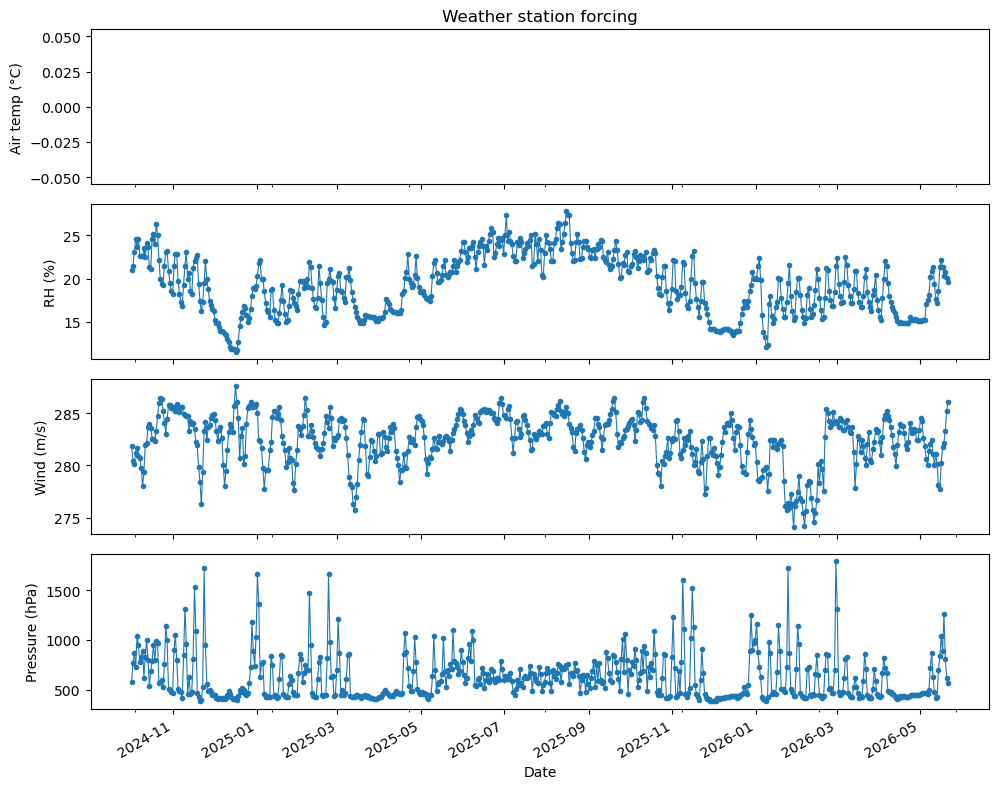

In [93]:
### Load weather station data


### Load weather station data

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

weather_path = os.path.join(
    "..",
    "data",
    "Meteo",
    "Additional",
    "Weather_data_20260521_clean_outdoor.csv"
)

if not os.path.exists(weather_path):
    raise FileNotFoundError(
        "Weather file not found. Check this path: {}".format(weather_path)
    )

# The CSV has a proper header row.
weather_raw = pd.read_csv(weather_path, header=0)

print("Weather file loaded:")
print(weather_path)

print("\nRaw columns:")
for i, col in enumerate(weather_raw.columns):
    print(i, ":", col)

print("\nFirst rows:")
display(weather_raw.head())


# ── Extract time ────────────────────────────────────────────────────────────

timestamp_num = pd.to_numeric(weather_raw.iloc[:, 0], errors="coerce")

valid_time = timestamp_num.notna()

weather_raw = weather_raw.loc[valid_time].copy()
timestamp_num = timestamp_num.loc[valid_time].copy()

weather_time = (
    pd.to_datetime(timestamp_num, unit="s", utc=True)
    .dt.tz_convert("Europe/Zurich")
    .dt.tz_localize(None)
)


# ── Extract useful weather variables ────────────────────────────────────────

# Important:
# Use .to_numpy() when assigning columns.
# Otherwise pandas aligns the RangeIndex of weather_raw with the DatetimeIndex
# of weather and fills everything with NaN.

weather = pd.DataFrame(index=weather_time.to_numpy())

weather["Tair_C"] = pd.to_numeric(weather_raw.iloc[:, 2], errors="coerce").to_numpy()
weather["RH_pct"] = pd.to_numeric(weather_raw.iloc[:, 3], errors="coerce").to_numpy()
weather["CO2_ppm"] = pd.to_numeric(weather_raw.iloc[:, 4], errors="coerce").to_numpy()
weather["pressure_hPa"] = pd.to_numeric(weather_raw.iloc[:, 5], errors="coerce").to_numpy()
weather["wind_dir_deg"] = pd.to_numeric(weather_raw.iloc[:, 6], errors="coerce").to_numpy()
weather["U_kmh"] = pd.to_numeric(weather_raw.iloc[:, 7], errors="coerce").to_numpy()
weather["U10_m_s"] = weather["U_kmh"] / 3.6
weather["gust_kmh"] = pd.to_numeric(weather_raw.iloc[:, 8], errors="coerce").to_numpy()
weather["gust_dir_deg"] = pd.to_numeric(weather_raw.iloc[:, 9], errors="coerce").to_numpy()
weather["rain_mm"] = pd.to_numeric(weather_raw.iloc[:, 10], errors="coerce").to_numpy()

# Remove duplicated timestamps if any.
weather = weather[~weather.index.duplicated(keep="first")]

# Sort chronologically.
weather = weather.sort_index()


# ── Basic checks ────────────────────────────────────────────────────────────

print("\nWeather time period:")
print(weather.index.min(), "to", weather.index.max())

print("\nNumber of weather rows:", len(weather))

print("\nWeather summary:")
display(weather.describe())


# ── Diagnostic plot ─────────────────────────────────────────────────────────

fig_weather, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

weather["Tair_C"].plot(ax=axes[0], marker=".", linewidth=0.8)
axes[0].set_ylabel("Air temp (°C)")
axes[0].set_title("Weather station forcing")

weather["RH_pct"].plot(ax=axes[1], marker=".", linewidth=0.8)
axes[1].set_ylabel("RH (%)")

weather["U10_m_s"].plot(ax=axes[2], marker=".", linewidth=0.8)
axes[2].set_ylabel("Wind (m/s)")

weather["pressure_hPa"].plot(ax=axes[3], marker=".", linewidth=0.8)
axes[3].set_ylabel("Pressure (hPa)")
axes[3].set_xlabel("Date")

fig_weather.tight_layout()

Weather file loaded:
../data/Meteo/Additional/Weather_data_20260521_clean_outdoor.csv

Raw columns:
0 : timestamp_unix_s
1 : datetime_local
2 : datetime_iso
3 : T_inside_C
4 : RH_inside_pct
5 : CO2_ppm
6 : noise_dB
7 : pressure_hPa
8 : wind_dir_deg
9 : U_kmh
10 : U10_m_s
11 : gust_kmh
12 : gust_dir_deg
13 : Tair_C

First rows:


,timestamp_unix_s,datetime_local,datetime_iso,T_inside_C,RH_inside_pct,CO2_ppm,noise_dB,pressure_hPa,wind_dir_deg,U_kmh,U10_m_s,gust_kmh,gust_dir_deg,Tair_C
0,1727776800,01.10.2024 12:00,01.10.2024 12:00,21.0,46,578,49,1014.7,222,4,1.111111,27,216,8.9
1,1727863200,02.10.2024 12:00,02.10.2024 12:00,21.4,50,765,44,1009.4,222,6,1.666667,36,300,7.2
2,1727949600,03.10.2024 12:00,03.10.2024 12:00,23.1,49,874,47,1008.6,219,4,1.111111,14,171,5.0
3,1728036000,04.10.2024 12:00,04.10.2024 12:00,24.6,44,724,50,1012.3,211,4,1.111111,17,158,4.7
4,1728122400,05.10.2024 12:00,05.10.2024 12:00,23.7,46,1038,46,1013.9,224,3,0.833333,11,184,3.1



Weather time period:
2024-10-01 12:00:00 to 2026-05-21 12:00:00

Number of weather rows: 598

Weather summary:


,Tair_C,U10_m_s,pressure_hPa,wind_dir_deg,gust_kmh,gust_dir_deg,CO2_ppm,RH_pct
count,597.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000,598.000000
mean,3.853434,0.845875,1016.810033,197.331104,17.637124,186.239130,622.759197,41.744147
std,6.159680,0.441448,8.516227,55.041882,8.960948,71.179496,231.459231,5.213347
min,-13.500000,0.277778,986.900000,10.000000,4.000000,3.000000,383.000000,26.000000
25%,-0.400000,0.555556,1012.325000,177.250000,11.000000,137.000000,448.000000,38.000000
50%,3.100000,0.833333,1017.950000,214.000000,15.000000,217.500000,555.000000,42.000000
75%,8.400000,1.111111,1023.100000,231.000000,22.000000,229.000000,724.000000,46.000000
max,18.900000,3.055556,1035.400000,359.000000,50.000000,342.000000,1795.000000,54.000000


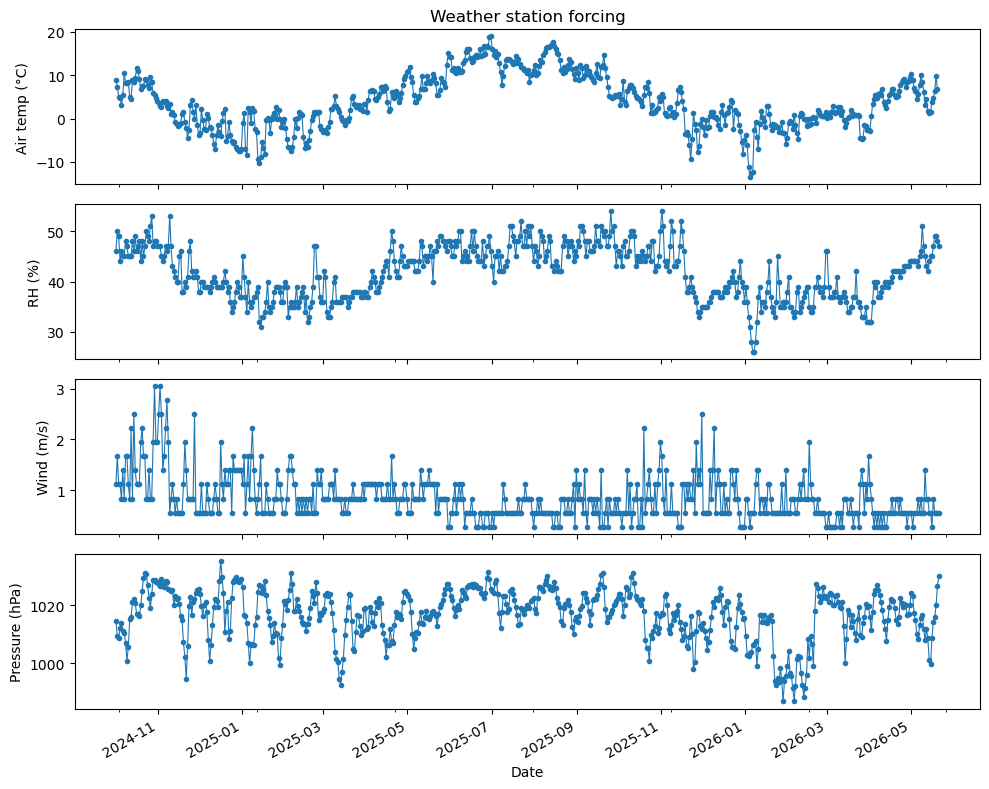

In [99]:
### Load weather station data


### Load weather station data

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

weather_path = os.path.join(
    "..",
    "data",
    "Meteo",
    "Additional",
    "Weather_data_20260521_clean_outdoor.csv"
)

if not os.path.exists(weather_path):
    raise FileNotFoundError(
        "Weather file not found. Check this path: {}".format(weather_path)
    )

# The CSV has a proper header row.
weather_raw = pd.read_csv(weather_path, header=0)

print("Weather file loaded:")
print(weather_path)

print("\nRaw columns:")
for i, col in enumerate(weather_raw.columns):
    print(i, ":", col)

print("\nFirst rows:")
display(weather_raw.head())


# ── Extract time ────────────────────────────────────────────────────────────

timestamp_num = pd.to_numeric(weather_raw.iloc[:, 0], errors="coerce")

valid_time = timestamp_num.notna()

weather_raw = weather_raw.loc[valid_time].copy()
timestamp_num = timestamp_num.loc[valid_time].copy()

weather_time = (
    pd.to_datetime(timestamp_num, unit="s", utc=True)
    .dt.tz_convert("Europe/Zurich")
    .dt.tz_localize(None)
)


# ── Extract useful weather variables ────────────────────────────────────────

# Important:
# Use .to_numpy() when assigning columns.
# Otherwise pandas aligns the RangeIndex of weather_raw with the DatetimeIndex
# of weather and fills everything with NaN.

weather = pd.DataFrame(index=weather_time.to_numpy())

def grab(col):
    if col not in weather_raw.columns:
        print(f"  /!\\ colonne absente du CSV : {col} -> NaN")
        return np.full(len(weather_raw), np.nan)
    return pd.to_numeric(weather_raw[col], errors="coerce").to_numpy()

weather["Tair_C"]       = grab("Tair_C")
weather["U10_m_s"]      = grab("U10_m_s")      
weather["pressure_hPa"] = grab("pressure_hPa")
weather["wind_dir_deg"] = grab("wind_dir_deg")
weather["gust_kmh"]     = grab("gust_kmh")
weather["gust_dir_deg"] = grab("gust_dir_deg")
weather["CO2_ppm"]      = grab("CO2_ppm")
weather["RH_pct"]       = grab("RH_inside_pct")

# Remove duplicated timestamps if any.
weather = weather[~weather.index.duplicated(keep="first")]

# Sort chronologically.
weather = weather.sort_index()


# ── Basic checks ────────────────────────────────────────────────────────────

print("\nWeather time period:")
print(weather.index.min(), "to", weather.index.max())

print("\nNumber of weather rows:", len(weather))

print("\nWeather summary:")
display(weather.describe())


# ── Diagnostic plot ─────────────────────────────────────────────────────────

fig_weather, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

weather["Tair_C"].plot(ax=axes[0], marker=".", linewidth=0.8)
axes[0].set_ylabel("Air temp (°C)")
axes[0].set_title("Weather station forcing")

weather["RH_pct"].plot(ax=axes[1], marker=".", linewidth=0.8)
axes[1].set_ylabel("RH (%)")

weather["U10_m_s"].plot(ax=axes[2], marker=".", linewidth=0.8)
axes[2].set_ylabel("Wind (m/s)")

weather["pressure_hPa"].plot(ax=axes[3], marker=".", linewidth=0.8)
axes[3].set_ylabel("Pressure (hPa)")
axes[3].set_xlabel("Date")

fig_weather.tight_layout()

Loaded radiation file:
  ../data/Meteo/Additional/ogd-smn_aig_d_historical.csv
  rows: 16436
Loaded radiation file:
  ../data/Meteo/Additional/ogd-smn_aig_d_recent.csv
  rows: 154

Combined radiation period:
1981-01-01 00:00:00 to 2026-06-03 00:00:00

Number of radiation rows: 16590

Radiation summary:


count    16590.000000
mean       145.614949
std         92.870272
min          0.000000
25%         66.000000
50%        128.000000
75%        221.000000
max        361.000000
Name: global_radiation_W_m2, dtype: float64

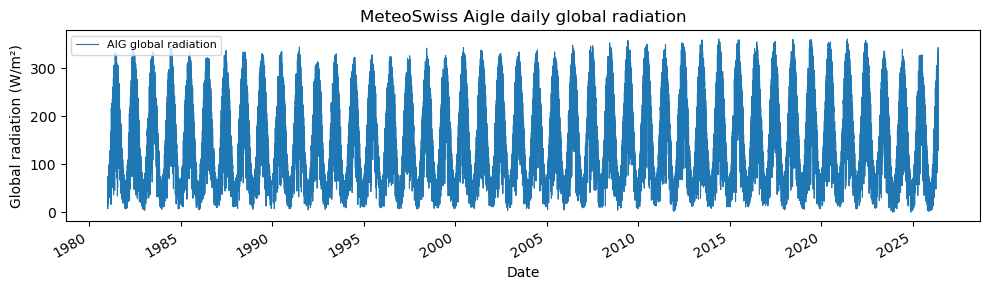

In [100]:
### Load MeteoSwiss Aigle daily global radiation, historical + recent

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Both files are stored at the same level as the cloud-cover CSV
radiation_files = [
    os.path.join("..", "data", "Meteo","Additional", "ogd-smn_aig_d_historical.csv"),
    os.path.join("..", "data", "Meteo","Additional", "ogd-smn_aig_d_recent.csv")
]

radiation_parts = []

for radiation_path in radiation_files:

    if not os.path.exists(radiation_path):
        raise FileNotFoundError(
            "Radiation file not found. Check this path: {}".format(radiation_path)
        )

    rad_raw = pd.read_csv(
        radiation_path,
        sep=";"
    )

    print("Loaded radiation file:")
    print(" ", radiation_path)
    print("  rows:", len(rad_raw))

    # Parse MeteoSwiss daily timestamp
    rad_time = pd.to_datetime(
        rad_raw["reference_timestamp"],
        format="%d.%m.%Y %H:%M",
        errors="coerce"
    )

    rad = pd.DataFrame(index=rad_time)

    # gre000d0 = daily global radiation
    rad["global_radiation_W_m2"] = pd.to_numeric(
        rad_raw["gre000d0"],
        errors="coerce"
    ).to_numpy()

    rad["station"] = rad_raw["station_abbr"].to_numpy()

    rad = rad[rad.index.notna()]
    radiation_parts.append(rad)


# Combine historical and recent files
radiation = pd.concat(radiation_parts)

# Remove duplicated dates, keeping the recent file if overlap exists
radiation = radiation[~radiation.index.duplicated(keep="last")]

# Sort chronologically
radiation = radiation.sort_index()

print("\nCombined radiation period:")
print(radiation.index.min(), "to", radiation.index.max())

print("\nNumber of radiation rows:", len(radiation))

print("\nRadiation summary:")
display(radiation["global_radiation_W_m2"].describe())


# Diagnostic plot
fig_radiation, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(
    radiation.index,
    radiation["global_radiation_W_m2"],
    linewidth=0.8,
    label="AIG global radiation"
)

ax.set_ylabel("Global radiation (W/m²)")
ax.set_xlabel("Date")
ax.set_title("MeteoSwiss Aigle daily global radiation")
ax.legend(fontsize=8)

fig_radiation.autofmt_xdate()
fig_radiation.tight_layout()

Cloud-cover file loaded:
../data/Meteo/Additional/cloud_cover_timeseries_Taney.csv

Columns:
0 : system:index
1 : cloud_cover_percent
2 : cloud_fraction
3 : date
4 : system_time_start
5 : .geo

First rows:


,system:index,cloud_cover_percent,cloud_fraction,date,system_time_start,.geo
0,tcdc_2024100100,92.300003,0.923,2024-10-01 00:00:00,1727740800000,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,tcdc_2024100106,76.400002,0.764,2024-10-01 06:00:00,1727762400000,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,tcdc_2024100112,99.400002,0.994,2024-10-01 12:00:00,1727784000000,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,tcdc_2024100118,71.000000,0.710,2024-10-01 18:00:00,1727805600000,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,tcdc_2024100200,82.099998,0.821,2024-10-02 00:00:00,1727827200000,"{""type"":""MultiPoint"",""coordinates"":[]}"



Cloud-cover period:
2024-10-01 02:00:00 to 2026-02-28 19:00:00

Cloud-cover summary:


,cloud_cover_percent,cloud_fraction
count,2064.000000,2064.000000
mean,43.625049,0.436250
std,34.872513,0.348725
min,0.000000,0.000000
25%,9.475000,0.094750
50%,39.350000,0.393500
75%,75.599998,0.756000
max,100.000000,1.000000


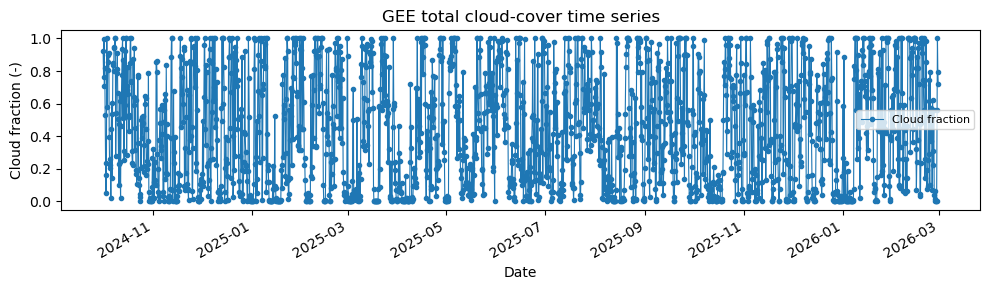

In [101]:
#### Load cloud-cover time series from Google Earth Engine export

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cloud_path = os.path.join(
    "..",
    "data",
    "Meteo",
    "Additional",
    "cloud_cover_timeseries_Taney.csv"
)

if not os.path.exists(cloud_path):
    raise FileNotFoundError(
        "Cloud-cover file not found. Check this path: {}".format(cloud_path)
    )

cloud_raw = pd.read_csv(cloud_path)

print("Cloud-cover file loaded:")
print(cloud_path)

print("\nColumns:")
for i, col in enumerate(cloud_raw.columns):
    print(i, ":", col)

print("\nFirst rows:")
display(cloud_raw.head())


# ── Parse time ──────────────────────────────────────────────────────────────

# GEE system_time_start is in milliseconds since 1970 UTC.
# We convert it to local Europe/Zurich time to match the weather dataframe.

cloud_time = (
    pd.to_datetime(cloud_raw["system_time_start"], unit="ms", utc=True)
    .dt.tz_convert("Europe/Zurich")
    .dt.tz_localize(None)
)


# ── Build clean cloud-cover dataframe ───────────────────────────────────────

cloud_cover = pd.DataFrame(index=cloud_time)

cloud_cover["cloud_cover_percent"] = pd.to_numeric(
    cloud_raw["cloud_cover_percent"],
    errors="coerce"
).to_numpy()

cloud_cover["cloud_fraction"] = pd.to_numeric(
    cloud_raw["cloud_fraction"],
    errors="coerce"
).to_numpy()

# Keep cloud fraction physically bounded between 0 and 1.
cloud_cover["cloud_fraction"] = cloud_cover["cloud_fraction"].clip(0, 1)

cloud_cover = cloud_cover[~cloud_cover.index.duplicated(keep="first")]
cloud_cover = cloud_cover.sort_index()

print("\nCloud-cover period:")
print(cloud_cover.index.min(), "to", cloud_cover.index.max())

print("\nCloud-cover summary:")
display(cloud_cover.describe())


# ── Diagnostic plot ─────────────────────────────────────────────────────────

fig_cloud, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(
    cloud_cover.index,
    cloud_cover["cloud_fraction"],
    marker=".",
    linewidth=0.8,
    label="Cloud fraction"
)

ax.set_ylabel("Cloud fraction (-)")
ax.set_xlabel("Date")
ax.set_title("GEE total cloud-cover time series")
ax.legend(fontsize=8)

fig_cloud.autofmt_xdate()
fig_cloud.tight_layout()

In [102]:
### Heat flux computation with cloud cover + MeteoSwiss radiation

# This cell computes the surface heat flux using:
#   - local weather station: air temperature, humidity, wind
#   - GEE cloud cover: cloud fraction C
#   - MeteoSwiss AIG radiation: global radiation G
#   - mooring data: surface water temperature Tw
#
# Sign convention:
#   positive flux  = heat gain by the lake
#   negative flux  = heat loss from the lake
#
# Components:
#   SW_flux        = absorbed shortwave radiation
#   LW_in_flux     = incoming atmospheric longwave radiation
#   LW_out_flux    = outgoing longwave radiation from water
#   H_latent       = latent heat flux
#   H_sensible     = sensible heat flux
#   H_net          = total surface heat flux

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ── Paths ───────────────────────────────────────────────────────────────────

cloud_path = os.path.join(
    "..",
    "data",
    "Meteo",
    "Additional",
    "cloud_cover_timeseries_Taney.csv"
)

radiation_files = [
    os.path.join("..", "data", "Meteo", "Additional", "ogd-smn_aig_d_historical.csv"),
    os.path.join("..", "data", "Meteo", "Additional", "ogd-smn_aig_d_recent.csv")
]


# ── Load cloud-cover time series ────────────────────────────────────────────

if not os.path.exists(cloud_path):
    raise FileNotFoundError("Cloud-cover file not found: {}".format(cloud_path))

cloud_raw = pd.read_csv(cloud_path)

cloud_time = (
    pd.to_datetime(cloud_raw["system_time_start"], unit="ms", utc=True)
    .dt.tz_convert("Europe/Zurich")
    .dt.tz_localize(None)
)

cloud_cover = pd.DataFrame(index=cloud_time)

cloud_cover["cloud_cover_percent"] = pd.to_numeric(
    cloud_raw["cloud_cover_percent"],
    errors="coerce"
).to_numpy()

cloud_cover["cloud_fraction"] = pd.to_numeric(
    cloud_raw["cloud_fraction"],
    errors="coerce"
).to_numpy()

cloud_cover["cloud_fraction"] = cloud_cover["cloud_fraction"].clip(0, 1)

cloud_cover = cloud_cover[~cloud_cover.index.duplicated(keep="first")]
cloud_cover = cloud_cover.sort_index()

print("Cloud cover loaded:")
print("  period:", cloud_cover.index.min(), "to", cloud_cover.index.max())
print("  mean cloud fraction:", cloud_cover["cloud_fraction"].mean())


# ── Load MeteoSwiss AIG radiation, historical + recent ──────────────────────

radiation_parts = []

for radiation_path in radiation_files:

    if not os.path.exists(radiation_path):
        raise FileNotFoundError("Radiation file not found: {}".format(radiation_path))

    rad_raw = pd.read_csv(radiation_path, sep=";")

    rad_time = pd.to_datetime(
        rad_raw["reference_timestamp"],
        format="%d.%m.%Y %H:%M",
        errors="coerce"
    )

    rad = pd.DataFrame(index=rad_time)

    # gre000d0 = MeteoSwiss daily global radiation variable
    rad["global_radiation_W_m2"] = pd.to_numeric(
        rad_raw["gre000d0"],
        errors="coerce"
    ).to_numpy()

    rad["station"] = rad_raw["station_abbr"].to_numpy()

    rad = rad[rad.index.notna()]
    radiation_parts.append(rad)

radiation = pd.concat(radiation_parts)
radiation = radiation[~radiation.index.duplicated(keep="last")]
radiation = radiation.sort_index()

print("\nRadiation loaded:")
print("  period:", radiation.index.min(), "to", radiation.index.max())
print("  mean radiation:", radiation["global_radiation_W_m2"].mean())


# ── Flux functions from Damien's notebook ───────────────────────────────────

def SW(G, C, Adir):
    """
    Absorbed shortwave radiation.

    G    = incoming global radiation, W/m2
    C    = cloud-cover fraction, 0-1
    Adir = direct albedo

    The original function fixes Adir to 0.1 internally.
    """
    Adiff = 0.066
    Adir = 0.1

    Fdir = (1 - C) / ((1 - C) + 0.5 * C)
    Fdiff = (0.5 * C) / ((1 - C) + 0.5 * C)

    sw = G * Fdir * (1 - Adir) + G * Fdiff * (1 - Adiff)

    return sw


def LW_in(Ta, Ea):
    """
    Incoming atmospheric longwave radiation.
    """
    A_L = 0.03
    sigma = 5.67e-8

    lwi = (1 - A_L) * Ea * sigma * (Ta + 273.25) ** 4

    return lwi


def emissivity_(Ta, ea, C):
    """
    Atmospheric emissivity.
    """
    a = 1.09

    Ea = a * (1 + 0.17 * C ** 2) * 1.24 * (ea / (Ta + 273.25)) ** (1 / 7)

    return Ea


def LW_out(Tw):
    """
    Outgoing longwave radiation from water.
    """
    E_w = 0.972
    sigma = 5.67e-8

    lwo = -E_w * sigma * (Tw + 273.25) ** 4

    return lwo


def He(Ta, Tw, WS, ea):
    """
    Latent heat flux.
    """
    es = 6.112 * np.exp(17.62 * Tw / (243.12 + Tw))
    f = 4.8 + 1.98 * WS + 0.28 * (Tw - Ta)

    he = -f * (es - ea)

    return he


def Hc(Ta, Tw, WS):
    """
    Sensible heat flux.
    """
    cp = 1005
    p = 1015
    Lv = 2.47e6

    gamma = cp * p / (0.622 * Lv)

    f = 4.8 + 1.98 * WS + 0.28 * (Tw - Ta)

    hc = -gamma * f * (Tw - Ta)

    return hc


def vapour_pressure(Ta, RH):
    """
    Air vapour pressure from air temperature and relative humidity.
    """
    es = 6.11 * np.exp((17.27 * Ta) / (237.3 + Ta))
    ea = RH * es / 100.0

    return ea


# ── Extract surface water temperature from mooring grid ─────────────────────

Twater_surface = np.full(len(time_num), np.nan)
surface_depth_flux = np.full(len(time_num), np.nan)

for kt in range(len(time_num)):

    ok = np.where(~np.isnan(temp_grid[:, kt]))[0]

    if len(ok) > 0:
        surface_idx = ok[0]
        Twater_surface[kt] = temp_grid[surface_idx, kt]
        surface_depth_flux[kt] = depth_grid[surface_idx]

lake_surface = pd.DataFrame(
    {
        "Twater_C": Twater_surface,
        "surface_depth_m": surface_depth_flux
    },
    index=pd.to_datetime(time_date)
)

lake_surface = lake_surface[~lake_surface.index.duplicated(keep="first")]
lake_surface = lake_surface.sort_index()


# ── Start from weather dataframe ────────────────────────────────────────────

if "weather" not in globals():
    raise ValueError("Run the weather loading cell first.")

flux = weather.copy()


# ── Interpolate surface water temperature onto weather timestamps ───────────

valid_water = lake_surface["Twater_C"].notna()

if valid_water.sum() < 2:
    raise ValueError("Not enough valid surface-water temperature values.")

x_water = lake_surface.index[valid_water].astype("int64") / 1e9
y_water = lake_surface.loc[valid_water, "Twater_C"].to_numpy()

x_flux = flux.index.astype("int64") / 1e9

Twater_interp = np.full(len(flux), np.nan)

inside_water = (x_flux >= x_water.min()) & (x_flux <= x_water.max())

Twater_interp[inside_water] = np.interp(
    x_flux[inside_water],
    x_water,
    y_water
)

flux["Twater_C"] = Twater_interp


# ── Interpolate cloud cover onto weather timestamps ─────────────────────────

valid_cloud = cloud_cover["cloud_fraction"].notna()

if valid_cloud.sum() < 2:
    raise ValueError("Not enough valid cloud-cover values.")

x_cloud = cloud_cover.index[valid_cloud].astype("int64") / 1e9
y_cloud = cloud_cover.loc[valid_cloud, "cloud_fraction"].to_numpy()

C = np.full(len(flux), np.nan)

inside_cloud = (x_flux >= x_cloud.min()) & (x_flux <= x_cloud.max())

C[inside_cloud] = np.interp(
    x_flux[inside_cloud],
    x_cloud,
    y_cloud
)

# If a small part is outside cloud-cover range, fill with mean cloud fraction.
C = np.where(np.isfinite(C), C, np.nanmean(y_cloud))
C = np.clip(C, 0, 1)

flux["cloud_fraction"] = C


# ── Interpolate global radiation onto weather timestamps ────────────────────

valid_rad = radiation["global_radiation_W_m2"].notna()

if valid_rad.sum() < 2:
    raise ValueError("Not enough valid radiation values.")

x_rad = radiation.index[valid_rad].astype("int64") / 1e9
y_rad = radiation.loc[valid_rad, "global_radiation_W_m2"].to_numpy()

G = np.full(len(flux), np.nan)

inside_rad = (x_flux >= x_rad.min()) & (x_flux <= x_rad.max())

G[inside_rad] = np.interp(
    x_flux[inside_rad],
    x_rad,
    y_rad
)

flux["global_radiation_W_m2"] = G


# ── Prepare variables for flux calculation ──────────────────────────────────

Ta = flux["Tair_C"].to_numpy()
Tw = flux["Twater_C"].to_numpy()
RH = flux["RH_pct"].to_numpy()
WS = flux["U10_m_s"].to_numpy()

# Avoid zero wind speed in turbulent fluxes.
WS = np.where(np.isfinite(WS), WS, np.nan)
WS = np.maximum(WS, 0.1)

ea = vapour_pressure(Ta, RH)
Ea = emissivity_(Ta, ea, C)


# ── Compute heat flux components ────────────────────────────────────────────

Adir_default = 0.1

flux["SW_flux"] = SW(G, C, Adir_default)
flux["LW_in_flux"] = LW_in(Ta, Ea)
flux["LW_out_flux"] = LW_out(Tw)
flux["H_latent"] = He(Ta, Tw, WS, ea)
flux["H_sensible"] = Hc(Ta, Tw, WS)

flux["H_net_noSW"] = (
    flux["LW_in_flux"]
    + flux["LW_out_flux"]
    + flux["H_latent"]
    + flux["H_sensible"]
)

flux["H_net"] = flux["H_net_noSW"] + flux["SW_flux"]


# ── Keep valid flux rows ────────────────────────────────────────────────────

import pandas as pd

raw = pd.read_csv(weather_path)   # mets ici le chemin du CSV outdoor
print("CSV brut  -> Tair_C valides :", raw["Tair_C"].notna().sum(), "/", len(raw))
print(raw["Tair_C"].head(3).tolist())

print("\nweather   -> Tair_C valides :", weather["Tair_C"].notna().sum(), "/", len(weather))
print(weather["Tair_C"].head(3).tolist())

print("\nColonnes de weather :", list(weather.columns))

flux_valid = flux.dropna(
    subset=[
        "Tair_C",
        "RH_pct",
        "U10_m_s",
        "Twater_C",
        "cloud_fraction",
        "global_radiation_W_m2",
        "SW_flux",
        "LW_in_flux",
        "LW_out_flux",
        "H_latent",
        "H_sensible",
        "H_net"
    ]
).copy()


# ── Print summary ───────────────────────────────────────────────────────────

print("\nFlux calculation completed.")
print("Valid flux period:")
print(flux_valid.index.min(), "to", flux_valid.index.max())
print("Number of valid flux points:", len(flux_valid))

print("\nMean flux components, W/m2:")
display(
    flux_valid[
        [
            "SW_flux",
            "LW_in_flux",
            "LW_out_flux",
            "H_latent",
            "H_sensible",
            "H_net_noSW",
            "H_net"
        ]
    ].mean().to_frame("mean_W_m2")
)

print("\nFlux sign convention:")
print("Positive = heat gain by lake")
print("Negative = heat loss from lake")

Cloud cover loaded:
  period: 2024-10-01 02:00:00 to 2026-02-28 19:00:00
  mean cloud fraction: 0.43625048880393136

Radiation loaded:
  period: 1981-01-01 00:00:00 to 2026-06-03 00:00:00
  mean radiation: 145.61494876431584
CSV brut  -> Tair_C valides : 597 / 598
[8.9, 7.2, 5.0]

weather   -> Tair_C valides : 597 / 598
[8.9, 7.2, 5.0]

Colonnes de weather : ['Tair_C', 'U10_m_s', 'pressure_hPa', 'wind_dir_deg', 'gust_kmh', 'gust_dir_deg', 'CO2_ppm', 'RH_pct']

Flux calculation completed.
Valid flux period:
2024-10-01 12:00:00 to 2026-01-17 12:00:00
Number of valid flux points: 474

Mean flux components, W/m2:


,mean_W_m2
SW_flux,113.009692
LW_in_flux,251.348971
LW_out_flux,-367.134254
H_latent,-99.812742
H_sensible,-51.143915
H_net_noSW,-266.741939
H_net,-153.732247



Flux sign convention:
Positive = heat gain by lake
Negative = heat loss from lake


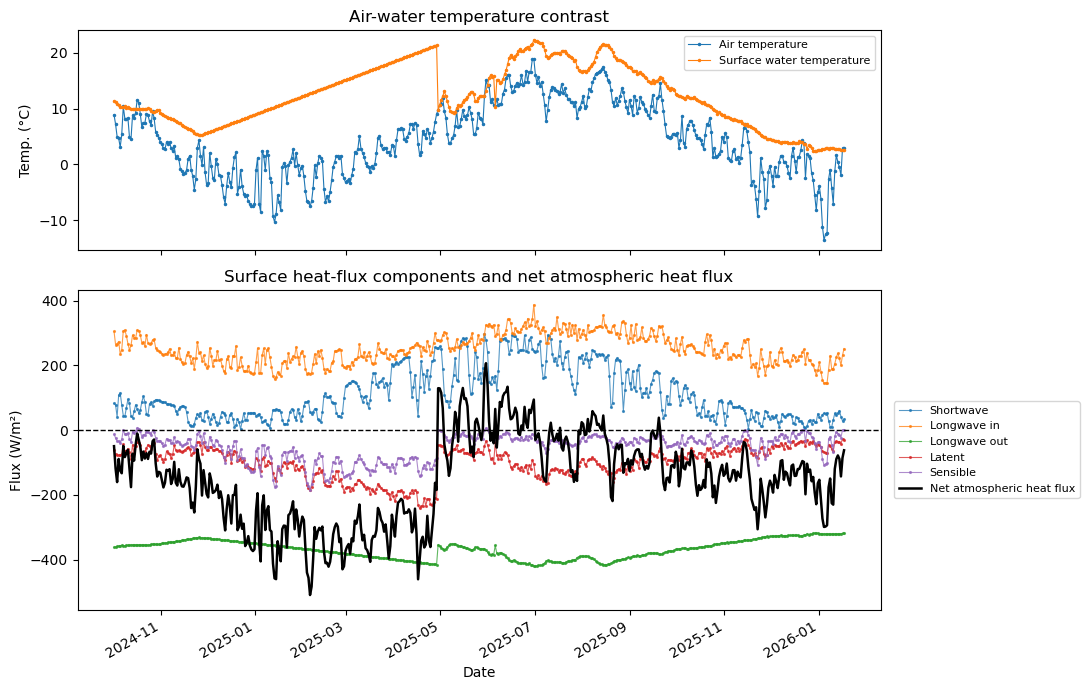

In [103]:
### Plot heat fluxes, compact version without radiation/cloud-cover panel

if "flux_valid" not in globals():
    raise ValueError("Run the flux computation cell first.")

fig_flux, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [1.1, 1.6]}
)

# ── 1. Air-water temperature contrast ───────────────────────────────────────

axes[0].plot(
    flux_valid.index,
    flux_valid["Tair_C"],
    marker=".",
    markersize=3,
    linewidth=0.8,
    label="Air temperature"
)

axes[0].plot(
    flux_valid.index,
    flux_valid["Twater_C"],
    marker=".",
    markersize=3,
    linewidth=0.8,
    label="Surface water temperature"
)

axes[0].set_ylabel("Temp. (°C)")
axes[0].set_title("Air-water temperature contrast")
axes[0].legend(fontsize=8, loc="best")


# ── 2. Heat-flux components + net flux ─────────────────────────────────────

component_cols = [
    "SW_flux",
    "LW_in_flux",
    "LW_out_flux",
    "H_latent",
    "H_sensible"
]

component_labels = {
    "SW_flux": "Shortwave",
    "LW_in_flux": "Longwave in",
    "LW_out_flux": "Longwave out",
    "H_latent": "Latent",
    "H_sensible": "Sensible"
}

for col in component_cols:
    axes[1].plot(
        flux_valid.index,
        flux_valid[col],
        marker=".",
        markersize=2.5,
        linewidth=0.8,
        alpha=0.75,
        label=component_labels[col]
    )

# Net flux with shortwave
axes[1].plot(
    flux_valid.index,
    flux_valid["H_net"],
    color="k",
    linewidth=1.8,
    label="Net atmospheric heat flux"
)


axes[1].axhline(
    0,
    linestyle="--",
    color="k",
    linewidth=1
)

axes[1].set_ylabel("Flux (W/m²)")
axes[1].set_xlabel("Date")
axes[1].set_title("Surface heat-flux components and net atmospheric heat flux")

axes[1].legend(
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5)
)

fig_flux.autofmt_xdate()
fig_flux.tight_layout()
fig_flux.savefig(os.path.join("..", "figures", "mooring_analysis", "heat_fluxes.png"), dpi=300, bbox_inches="tight")